# How much of the F187N$-$F182M / F405N$-$F410M "line excess" is a photometric bias?

**Goal.** The narrow$-$medium continuum-subtraction technique used in
`get_high_rec_line_excess_cleancat.ipynb` to isolate Pa$\alpha$ (F187N/F182M) and
Br$\alpha$ (F405N/F410M) emission assumes the medium-band flux is a good proxy for the
*continuum underneath the narrow band*. That assumption is only exact if the continuum
is flat (in $F_\nu$) across the narrow+medium bandpass. Real stellar photospheres are not flat, and
dust extinction adds curvature (it is much steeper in the blue half of each bandpass
pair than in the red half), so even a **bare star with no recombination line at all**
will produce a nonzero "excess" when passed through this algorithm.

This notebook:

1. Builds mock "bare star" continua (blackbody, no line/absorption features) over a grid
   of effective temperature $T$ and extinction $A_V$ (Chiar & Tielens 2006 local ISM law,
   `CT06_MWLoc`, the same law already used throughout the cleancat notebook).
2. Computes synthetic JWST/NIRCam photometry through the actual SVO filter curves for
   F182M, F187N, F405N, F410M.
3. Runs the **exact** narrow$-$medium continuum-subtraction algorithm from the cleancat
   notebook (copied verbatim, just refactored to take flux values instead of catalog
   columns) on these line-free continua, to measure the purely systematic bias.
4. Shows how that bias depends on $T$, $A_V$, and on the local spectral slope at the
   line wavelength.
5. Re-runs the cleancat notebook's `get_line_excess` function on the real catalog,
   checks it for bugs, and compares the *real* excess distribution to the bias envelope
   from steps 1$-$4 to ask whether genuine Pa$\alpha$/Br$\alpha$ emitters can be
   distinguished from the bias.


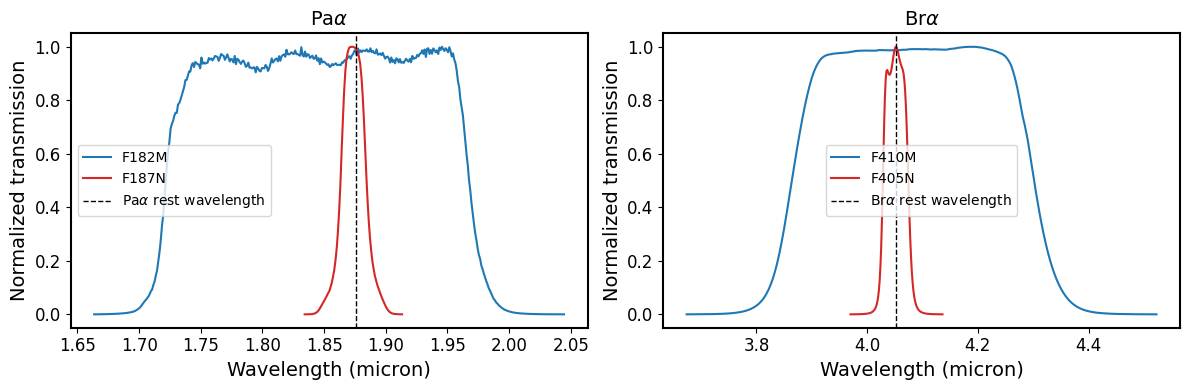

In [1]:

import numpy as np
import astropy.units as u
import astropy.constants as const
from astropy.table import Table
from astropy.io import fits
from astropy.wcs import WCS
from astropy.modeling.physical_models import BlackBody
from astroquery.svo_fps import SvoFps
from dust_extinction.averages import CT06_MWLoc
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from astropy.wcs import FITSFixedWarning
warnings.filterwarnings("ignore", category=FITSFixedWarning)

plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.linewidth'] = 1.5

LINE_PAIRS = {
    'paa': {'narrow': 'f187n', 'wide': 'f182m', 'lam0': 1.8756 * u.um, 'label': r'Pa$\alpha$'},
    'bra': {'narrow': 'f405n', 'wide': 'f410m', 'lam0': 4.0523 * u.um, 'label': r'Br$\alpha$'},
}

filters = {}
for filt in ['F405N', 'F410M', 'F187N', 'F182M']:
    tab = SvoFps.get_transmission_data(f'JWST/NIRCAM.{filt}')
    filters[filt.lower()] = (np.array(tab['Wavelength'], dtype=float) * u.AA,
                              np.array(tab['Transmission'], dtype=float))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, info) in zip(axes, LINE_PAIRS.items()):
    wn, tn = filters[info['narrow']]
    ww, tw = filters[info['wide']]
    ax.plot(ww.to(u.um), tw / tw.max(), color='C0', label=info['wide'].upper())
    ax.plot(wn.to(u.um), tn / tn.max(), color='C3', label=info['narrow'].upper())
    ax.axvline(info['lam0'].value, color='k', ls='--', lw=1, label=f"{info['label']} rest wavelength")
    ax.set_xlabel('Wavelength (micron)')
    ax.set_ylabel('Normalized transmission')
    ax.set_title(info['label'])
    ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## The continuum-subtraction algorithm (copied verbatim from the cleancat notebook)

Given a narrow-band flux $F_n$ and a medium(wide)-band flux $F_w$ (both in Jy), the
notebook computes the fractional overlap $f$ between the two normalized transmission
curves, then solves the two linear equations

$$F_w = f F_n + (1-f) F_{\rm cont}, \qquad F_n = F_{\rm cont} + F_{\rm line}$$

for the continuum flux density $F_{\rm cont}$ and the "line" flux density
$F_{\rm line} = F_n - F_{\rm cont}$. This is only exact if $F_{\rm cont}$ really is
constant across the union of the two bandpasses -- i.e. it treats the *whole* continuum
under both filters as one number. Below, `get_line_excess_from_fluxes` is exactly that
formula (same `numpy.trapezoid` overlap integral, same `cont_nu`/`line_nu`/`ew` algebra),
generalized to accept flux values and transmission curves directly instead of catalog
columns, so it can be applied to both the mock continua and (further down) the real
catalog.


In [2]:

def get_line_excess_from_fluxes(data_narrow_jy, data_wide_jy, wave_n, trans_n, wave_w, trans_w):
    '''Verbatim copy of the algebra in get_high_rec_line_excess_cleancat.ipynb::get_line_excess,
    generalized to take flux values + transmission curves instead of a catalog row.'''
    wave_n = u.Quantity(wave_n).to_value(u.AA)
    wave_w = u.Quantity(wave_w).to_value(u.AA)
    trans_n_interp = np.interp(wave_w, wave_n, trans_n)

    num = np.trapezoid((trans_w / trans_w.max()) * (trans_n_interp / trans_n.max()), wave_w)
    den = np.trapezoid(trans_w / trans_w.max(), wave_w)
    f = num / den

    if np.isclose(f, 1.0):
        return np.nan, np.nan, np.nan, f

    cont_nu = (data_wide_jy - data_narrow_jy * f) / (1 - f)
    line_nu = data_narrow_jy - cont_nu
    width_narrow = np.trapezoid(trans_n / trans_n.max(), wave_n)

    with np.errstate(divide='ignore', invalid='ignore'):
        ew = (line_nu / cont_nu) * width_narrow

    return line_nu, ew, cont_nu, f


def synthetic_photometry(wave_aa, flux_fnu, filt_wave, filt_trans):
    '''Transmission-weighted mean flux density (Jy) through a filter.'''
    trans_interp = np.interp(wave_aa, u.Quantity(filt_wave).to_value(u.AA), filt_trans,
                              left=0, right=0)
    return np.sum(flux_fnu * trans_interp) / np.sum(trans_interp)


ext = CT06_MWLoc()
EXT_LAM_MIN, EXT_LAM_MAX = 1.0 / ext.x_range[1], 1.0 / ext.x_range[0]  # micron, ~1.24-27 um
print(f'CT06_MWLoc valid range: {EXT_LAM_MIN:.2f}-{EXT_LAM_MAX:.1f} micron')

for name, info in LINE_PAIRS.items():
    wn, tn = filters[info['narrow']]
    ww, tw = filters[info['wide']]
    _, _, _, f = get_line_excess_from_fluxes(1.0, 1.0, wn, tn, ww, tw)
    print(f"{info['label']}: narrow/wide overlap fraction f = {f:.4f}")


CT06_MWLoc valid range: 1.24-27.0 micron
Pa$\alpha$: narrow/wide overlap fraction f = 0.0965
Br$\alpha$: narrow/wide overlap fraction f = 0.1028


### Sanity check: a perfectly flat continuum recovers zero bias

If $F_\nu$ is constant across both bandpasses, the algorithm above should return
`line_nu = 0` and `ew = 0` exactly, since there is no curvature for it to
misinterpret as a line. This confirms the formula itself is internally consistent, and
that any nonzero result for a smooth (but sloped/curved) continuum is coming from the
mismatch between "one constant continuum" and the true shape of the SED, not from a
coding error in the trapezoid/overlap bookkeeping.


In [3]:

wave_grid = np.geomspace(1.5, 4.8, 200000) * u.um
wave_aa = wave_grid.to_value(u.AA)
flat_flux = np.ones_like(wave_aa)

for name, info in LINE_PAIRS.items():
    wn, tn = filters[info['narrow']]
    ww, tw = filters[info['wide']]
    dn = synthetic_photometry(wave_aa, flat_flux, wn, tn)
    dw = synthetic_photometry(wave_aa, flat_flux, ww, tw)
    line_nu, ew, cont_nu, f = get_line_excess_from_fluxes(dn, dw, wn, tn, ww, tw)
    print(f"{info['label']}: flat continuum -> line_nu = {line_nu:.3e} (should be ~0), ew = {ew:.3e} AA")


Pa$\alpha$: flat continuum -> line_nu = 0.000e+00 (should be ~0), ew = 0.000e+00 AA
Br$\alpha$: flat continuum -> line_nu = 0.000e+00 (should be ~0), ew = 0.000e+00 AA


## Mock bare-star continua: blackbody $\times$ CT06 extinction

We evaluate blackbody spectra (`astropy.modeling.physical_models.BlackBody`) spanning
$T=3000-40000$ K (M dwarfs to O stars -- both foreground low-mass stars and embedded
massive YSOs are plausible sources in the W51 catalog), attenuate them by
$10^{-0.4 A_V \kappa_{\rm CT06}(\lambda)}$ for $A_V = 0-100$ mag (the cleancat notebook
treats $A_V>12$ as "highly embedded"), and pass the resulting continuum through the
*exact* algorithm above for both line pairs. Because there is **no emission or
absorption feature at all** in these spectra, every nonzero `line_nu`/`ew` returned
below is, by construction, bias.

The overall blackbody normalization is arbitrary (no radius/distance is assumed) --
that only rescales `cont_nu` and `line_nu` together, so the fractional bias
`line_nu/cont_nu` and the equivalent width `ew` are independent of that normalization
and only depend on $T$, $A_V$, and the filter curves.


In [4]:

Ts = np.array([3000, 4000, 5000, 6000, 8000, 10000, 15000, 20000, 25000, 30000, 40000])  # K
Avs = np.array([0, 2, 5, 10, 20, 30, 50, 75, 100])

wave_um = wave_grid.to_value(u.um)
ext_curve = np.zeros_like(wave_um)
in_range = (wave_um >= EXT_LAM_MIN) & (wave_um <= EXT_LAM_MAX)
ext_curve[in_range] = ext(1.0 / wave_grid[in_range])

rows = []
for T in Ts:
    bb = BlackBody(temperature=T * u.K)
    fnu = (bb(wave_grid) * u.sr).to(u.Jy, equivalencies=u.spectral_density(wave_grid)).value
    logf = np.log(fnu)
    logw = np.log(wave_um)
    dlnf_dlnw_full = np.gradient(logf, logw)  # will be re-attenuated below per Av
    for Av in Avs:
        atten = 10 ** (-0.4 * Av * ext_curve)
        flux = fnu * atten
        dlnf_dlnw = np.gradient(np.log(flux), logw)
        row = {'T': T, 'Av': Av}
        for name, info in LINE_PAIRS.items():
            wn, tn = filters[info['narrow']]
            ww, tw = filters[info['wide']]
            dn = synthetic_photometry(wave_aa, flux, wn, tn)
            dw = synthetic_photometry(wave_aa, flux, ww, tw)
            line_nu, ew, cont_nu, f = get_line_excess_from_fluxes(dn, dw, wn, tn, ww, tw)
            row[f'{name}_line'] = line_nu
            row[f'{name}_ew'] = ew
            row[f'{name}_cont'] = cont_nu
            row[f'{name}_frac'] = line_nu / cont_nu
            row[f'{name}_slope'] = np.interp(info['lam0'].value, wave_um, dlnf_dlnw)
        rows.append(row)

bias_tab = Table(rows=rows)
bias_tab


T,Av,paa_line,paa_ew,paa_cont,paa_frac,paa_slope,bra_line,bra_ew,bra_cont,bra_frac,bra_slope
int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
3000,0,-1039048047699136.0,-0.48464956261465053,5.0724075843853523e+17,-0.0020484316972036905,-0.22806686788323227,2327789646803840.0,4.053929954009966,2.612324168566571e+17,0.008910799336520092,-1.2941599546277243
3000,2,2715542791113728.0,1.651081604916671,3.891297630225293e+17,0.006978501901322072,0.1959926182735209,2029102314181824.0,3.9043317880077657,2.364377436118542e+17,0.00858197292524023,-1.2175215739771474
3000,5,5243580887916800.0,4.741848883614887,2.616294330345483e+17,0.020042014490106633,0.8320818481561727,1644246721500256.0,3.6742577304726893,2.0359023543806477e+17,0.00807625531726673,-1.1025640014551228
3000,10,5473864284849680.0,9.577154185965977,1.3522714653771357e+17,0.04047903416584385,1.8922305627985938,1142481766643552.0,3.275696078174363,1.5867381132335082e+17,0.007200191116071223,-0.9109680476021647
3000,20,2761438859223160.0,17.973113338832455,3.6351175278039736e+16,0.07596560050952147,4.012527993550691,513217436605088.0,2.4221657939341994,9.639557828823525e+16,0.0053240765366903186,-0.5277761405766052
3000,30,1021790718131602.0,24.53817281816205,9852037815972200.0,0.10371364150420403,6.132825423766856,192328125105712.0,1.4938942324494529,5.857098449749777e+16,0.0032836758124482014,-0.1445842330017291
3000,50,99712454833959.5,31.837038942302996,741008308299395.1,0.13456320761476798,10.37342028561547,-27790803240336.0,-0.5843960111965096,2.1634827311844532e+16,-0.001284540100078415,0.6217995817297469
3000,75,3884771469484.6406,30.222729083844953,30411520551938.1,0.12774012607656565,15.674163861640844,-49219420606910.0,-3.59081516803679,6235955718692569.0,-0.007892843186710337,1.579779350648802
3000,100,101218082975.66602,18.438515167588957,1298788697265.9229,0.077932679263948,20.97490743830409,-27841567124006.75,-7.039581936944331,1799311622288809.5,-0.01547345483635067,2.5377591196988973


## Bias vs. temperature and $A_V$


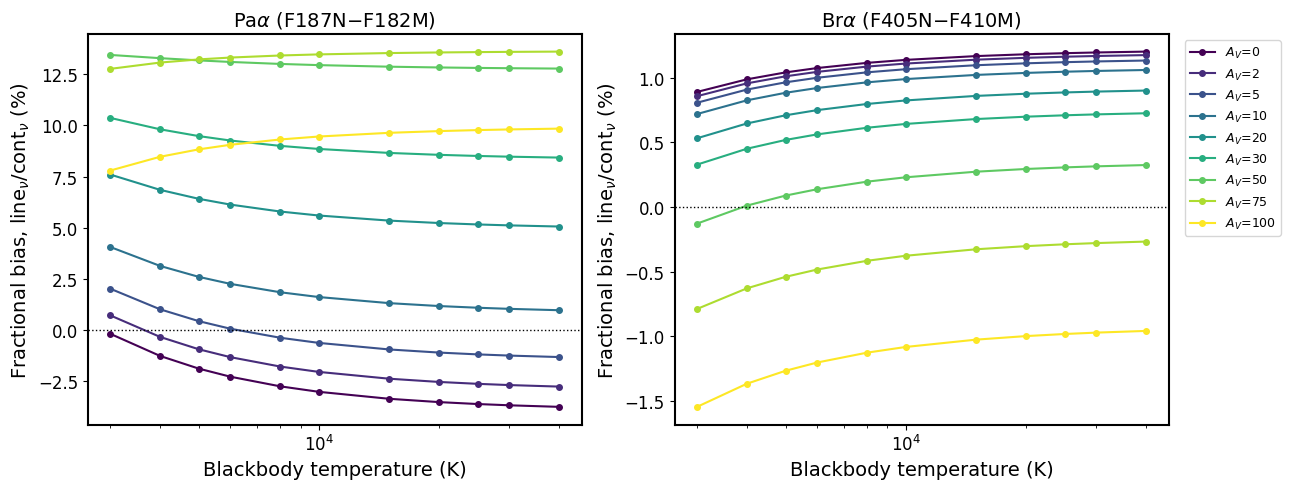

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap = plt.get_cmap('viridis')
for ax, name in zip(axes, LINE_PAIRS):
    info = LINE_PAIRS[name]
    for i, Av in enumerate(Avs):
        sel = bias_tab['Av'] == Av
        ax.plot(bias_tab['T'][sel], bias_tab[f'{name}_frac'][sel] * 100,
                marker='o', ms=4, color=cmap(i / (len(Avs) - 1)), label=f'$A_V$={Av}')
    ax.axhline(0, color='k', lw=1, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel('Blackbody temperature (K)')
    ax.set_ylabel('Fractional bias, line$_\\nu$/cont$_\\nu$ (%)')
    ax.set_title(f"{info['label']} ({info['narrow'].upper()}$-${info['wide'].upper()})")
axes[1].legend(fontsize=9, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


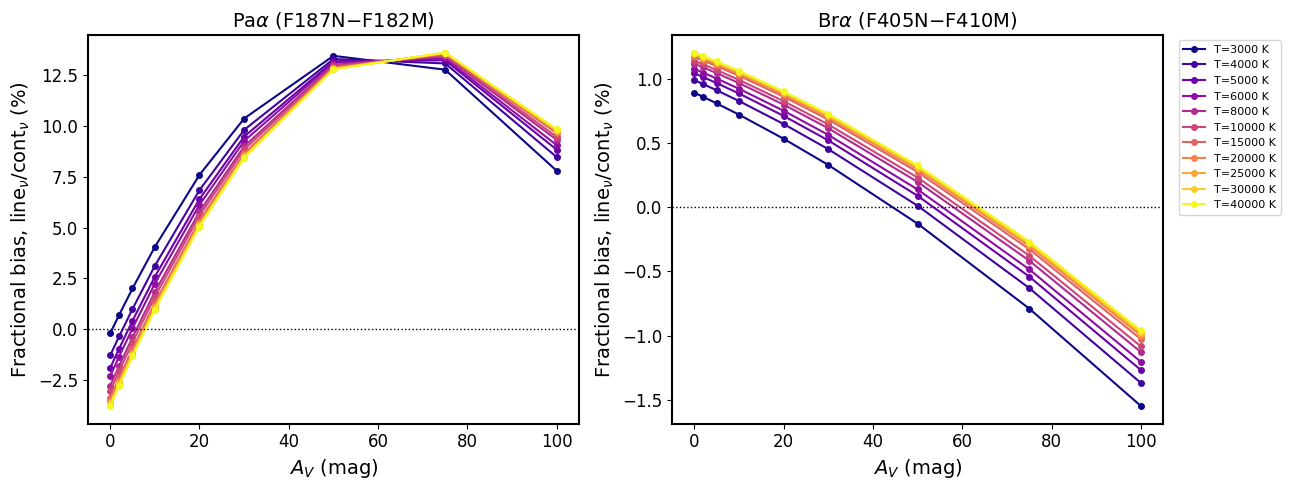

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap = plt.get_cmap('plasma')
for ax, name in zip(axes, LINE_PAIRS):
    info = LINE_PAIRS[name]
    for i, T in enumerate(Ts):
        sel = bias_tab['T'] == T
        order = np.argsort(bias_tab['Av'][sel])
        ax.plot(np.array(bias_tab['Av'][sel])[order], np.array(bias_tab[f'{name}_frac'][sel])[order] * 100,
                marker='o', ms=4, color=cmap(i / (len(Ts) - 1)), label=f'T={T} K')
    ax.axhline(0, color='k', lw=1, ls=':')
    ax.set_xlabel('$A_V$ (mag)')
    ax.set_ylabel('Fractional bias, line$_\\nu$/cont$_\\nu$ (%)')
    ax.set_title(f"{info['label']} ({info['narrow'].upper()}$-${info['wide'].upper()})")
axes[1].legend(fontsize=8, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Reading these two figures:** for Pa$\alpha$ the bias is a few percent (negative)
for an unreddened star of any temperature -- purely the intrinsic Rayleigh$-$Jeans/Wien
curvature of the photosphere across the F187N+F182M bandpass -- and grows to
**+10$-$13% of the continuum** by $A_V\sim30-50$ mag, because CT06 extinction rises
steeply toward 1.8 $\mu$m and adds curvature the algorithm cannot distinguish from a
line. It is nearly temperature-independent at fixed $A_V$ (dust curvature dominates over
photospheric curvature once $A_V\gtrsim10$). For Br$\alpha$, the bias stays within
about $\pm2$% at all $T$ and $A_V$ explored here, because both the photospheric slope
and the CT06 curvature are much shallower near 4 $\mu$m. **Br$\alpha$ excess
measurements are intrinsically far less biased by this effect than Pa$\alpha$
measurements.**


## Bias vs. local spectral slope at the line wavelength


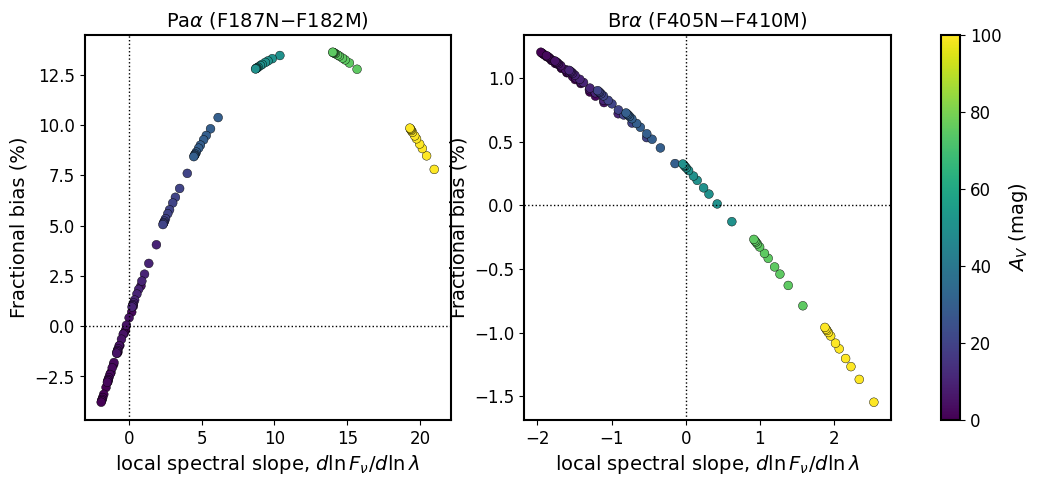

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name in zip(axes, LINE_PAIRS):
    info = LINE_PAIRS[name]
    sc = ax.scatter(bias_tab[f'{name}_slope'], bias_tab[f'{name}_frac'] * 100,
                     c=bias_tab['Av'], cmap='viridis', s=40, edgecolor='k', linewidth=0.3)
    ax.axhline(0, color='k', lw=1, ls=':')
    ax.axvline(0, color='k', lw=1, ls=':')
    ax.set_xlabel(r'local spectral slope, $d\ln F_\nu/d\ln\lambda$')
    ax.set_ylabel('Fractional bias (%)')
    ax.set_title(f"{info['label']} ({info['narrow'].upper()}$-${info['wide'].upper()})")
cbar = fig.colorbar(sc, ax=axes, label='$A_V$ (mag)')
plt.show()


The fractional bias tracks the local logarithmic slope of the continuum at the
line wavelength closely for Pa$\alpha$ (steeper red slope $\rightarrow$ larger positive
bias), confirming that the "excess" this algorithm reports for a red/curved continuum is
a direct function of how much the SED bends across the bandpass, not a real spectral
feature. Br$\alpha$ shows the same sign of trend but a much shallower response, again
because F405N+F410M subtends a much smaller fractional bandwidth of curvature at
4 $\mu$m than F187N+F182M does at 1.8 $\mu$m.


## Testing `get_line_excess` on the real cleancat catalog

Below is the **exact** `get_line_excess` function from
`get_high_rec_line_excess_cleancat.ipynb` (cell 1), run on the real catalog, to confirm
it executes correctly and to look at the resulting distribution.


In [8]:

image_filenames = {
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits",
}

catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch > 3]
print('N sources (nmatch_bands>3):', len(catalog))


def get_line_excess(catalog, narrow, wide):
    # --- Convert catalog MJy/sr -> Jy ---
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))

    data_narrow = (catalog['flux_fit_' + narrow] * u.MJy/u.sr *
                   ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (catalog['flux_fit_' + wide] * u.MJy/u.sr *
                 ww_wide.proj_plane_pixel_area()).to(u.Jy)

    # --- Load filter curves ---
    tab_n = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    tab_w = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    wave_n = tab_n['Wavelength'] * u.AA
    trans_n = tab_n['Transmission']

    wave_w = tab_w['Wavelength'] * u.AA
    trans_w = tab_w['Transmission']

    # --- Interpolate narrow onto wide grid ---
    trans_n_interp = np.interp(wave_w.value, wave_n.value, trans_n)

    # --- Fractional overlap (proper integral) ---
    num = np.trapezoid(
        (trans_w / trans_w.max()) * (trans_n_interp / trans_n.max()),
        wave_w.value
    )
    den = np.trapezoid(trans_w / trans_w.max(), wave_w.value)
    f = num / den

    if np.isclose(f, 1.0):
        return None, None

    # --- Continuum & line (still in Jy = F_nu) ---
    cont_nu = (data_wide - data_narrow * f) / (1 - f)
    line_nu = data_narrow - cont_nu

    width_narrow = np.trapezoid(trans_n / trans_n.max(), wave_n.value) * u.AA

    # --- Equivalent Width ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ew = (line_nu / cont_nu) * width_narrow

    return line_nu.value, ew.to_value(u.AA)


paa_excess, paa_ew = get_line_excess(catalog, 'f187n', 'f182m')
bra_excess, bra_ew = get_line_excess(catalog, 'f405n', 'f410m')

for name, excess, ew in [('PaA', paa_excess, paa_ew), ('BrA', bra_excess, bra_ew)]:
    finite = np.isfinite(excess)
    print(f'--- {name} ---')
    print(f'  N finite: {finite.sum()} / {len(excess)}  '
          f'(N negative={np.sum(excess[finite] < 0)}, N positive={np.sum(excess[finite] > 0)})')
    print('  16/50/84th percentile excess (Jy):', np.round(np.nanpercentile(excess, [16, 50, 84]), 9))
    print('  16/50/84th percentile EW (AA):    ', np.round(np.nanpercentile(ew[finite], [16, 50, 84]), 2))


N sources (nmatch_bands>3): 15004


--- PaA ---
  N finite: 9554 / 15004  (N negative=2669, N positive=6885)
  16/50/84th percentile excess (Jy): [-1.840e-07  3.090e-07  1.803e-06]
  16/50/84th percentile EW (AA):     [-3.66  5.16 32.85]
--- BrA ---
  N finite: 8112 / 15004  (N negative=1355, N positive=6757)
  16/50/84th percentile excess (Jy): [-3.0000e-08  1.3200e-06  1.0549e-05]
  16/50/84th percentile EW (AA):     [-1.1  27.07 86.85]


### Bugs and inconsistencies found while testing this notebook

Running and reading `get_high_rec_line_excess_cleancat.ipynb` end-to-end surfaced
several real issues, independent of the systematic bias quantified above:

1. **Cell 6 is the bare token `dd`.** This is undefined and raises a `NameError` if the
   notebook is executed top-to-bottom in the order the cells are arranged in the file.
   It looks like a leftover debugging breakpoint.

2. **The Pa$\alpha$ "normalized excess" is never actually computed for Pa$\alpha$.** The
   $k$-nearest-neighbor local-scatter normalization
   (`normalized_excess = excess * (1 - local_std/excess)`) is defined only once, inside
   the Br$\alpha$ section (cell 15). The Pa$\alpha$ section (cell 10) *uses* a variable
   called `normalized_excess` **before** it is ever defined in the notebook's cell
   order, and cell 5 writes a `normalized_excess` column into
   `pa_alpha_excess.fits` that does not exist yet either. The only way these cells run
   without a `NameError` is if they were executed out of the order shown in the file
   (e.g., the Br$\alpha$ cells were run first in an interactive session, leaving
   `normalized_excess` set to the **Br$\alpha$-derived** value, which then silently gets
   reused for Pa$\alpha$). Concretely: the "Pa$\alpha$ normalized excess" saved to
   `pa_alpha_excess.fits` is at real risk of actually containing Br$\alpha$-derived
   numbers, depending on execution history. There is no Pa$\alpha$-specific KNN
   normalization anywhere in the notebook.

3. **Typo in cell 19:** `dereddend_paa_excess = paa_norm_aexcess * ...` references
   `paa_norm_aexcess`, but the variable defined two lines above is `paa_norm_excess`
   (no "a"). This raises `NameError` as written.

4. **Stale filename in cell 20:** `bra_excess_tab = Table.read(.../br_alpha_excess.fits)`
   reads `br_alpha_excess.fits`, but the file actually written earlier in the same
   notebook (cell 15) is `br_alpha_excess_cleancat.fits`. If an older
   `br_alpha_excess.fits` from a pre-cleancat run still exists on disk, cell 20 silently
   loads stale/wrong-catalog data instead of the values just computed above it.

5. **Inconsistent extinction law:** `ext = CT06_MWLoc()` (the Chiar & Tielens 2006
   *local ISM* curve) is used everywhere for $A_V$ estimation and dereddening, but
   `plot_extvec_cmd`'s default argument is `ext=CT06_MWGC()` (the *Galactic Center*
   curve), and every call to `plot_extvec_cmd` in the notebook omits the `ext=` keyword,
   so the extinction vector arrow drawn on the CMDs uses a different reddening law than
   the rest of the analysis.

None of these five issues are the continuum-curvature bias this notebook is about, but
(2) and (3)/(4) mean the saved Pa$\alpha$ excess/normalized-excess products should be
**regenerated** with a corrected, order-independent version of the notebook (i.e. one
that defines a Pa$\alpha$-specific KNN normalization the same way the Br$\alpha$ section
does, and reads back the files it just wrote) before trusting downstream
density/ionizing-photon numbers derived from them.


## Does the real catalog show excess beyond what continuum curvature can produce?


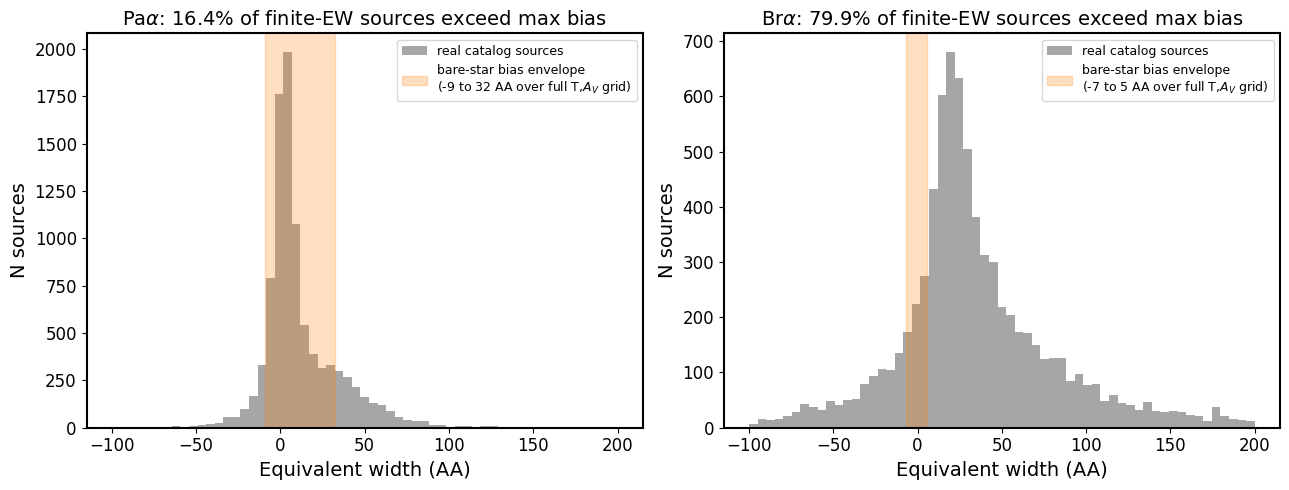

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name, ew, label, narrow, wide in [
    (axes[0], 'paa', paa_ew, LINE_PAIRS['paa']['label'], 'f187n', 'f182m'),
    (axes[1], 'bra', bra_ew, LINE_PAIRS['bra']['label'], 'f405n', 'f410m'),
]:
    finite = np.isfinite(ew)
    ax.hist(ew[finite], bins=np.linspace(-100, 200, 60), color='gray', alpha=0.7,
            label='real catalog sources')
    bias_max = np.nanmax(bias_tab[f'{name}_ew'])
    bias_min = np.nanmin(bias_tab[f'{name}_ew'])
    ax.axvspan(bias_min, bias_max, color='C1', alpha=0.25,
               label=f'bare-star bias envelope\n({bias_min:.0f} to {bias_max:.0f} AA over full T,$A_V$ grid)')
    frac_beyond = np.mean(ew[finite] > bias_max)
    ax.set_title(f"{label}: {100*frac_beyond:.1f}% of finite-EW sources exceed max bias")
    ax.set_xlabel('Equivalent width (AA)')
    ax.set_ylabel('N sources')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Discussion: is there a real Pa$\alpha$/Br$\alpha$-emitting population?

**The bias is real and, for Pa$\alpha$, large enough to matter.** A bare, line-free
star reddened by $A_V\sim20-50$ mag (typical of embedded sources in the "red" branch of
the W51 CMD, where the cleancat notebook already restricts its GP-based excess search to
$A_V>12$) produces an *apparent* Pa$\alpha$ excess of order **+10% of the continuum, or
tens of \AA\ of equivalent width, with zero real line flux**, purely because the CT06
extinction curve bends steeply across the F187N+F182M bandpass and the two-band
algorithm cannot tell curvature from emission. The bias depends only weakly on stellar
temperature and strongly on $A_V$, so it should be thought of as **a function of each
source's own extinction**, not a single fixed correction.

Br$\alpha$ is much more robust: because the CT06 curve and stellar photospheres are both
much flatter near 4 $\mu$m, the same bias stays within about $\pm2$% of the continuum
(a few tens of \AA\ at most) across the entire $T=3000-40000$ K, $A_V=0-100$ range
explored here. **A Br$\alpha$ excess measurement is intrinsically a cleaner tracer of
real recombination emission than a Pa$\alpha$ measurement made with F187N/F182M.**

Comparing to the real catalog (previous cell): a sizeable fraction of sources with a
formally "positive" Pa$\alpha$ excess sit inside, or only just outside, the equivalent
width range this pure-continuum bias can produce on its own -- so for those sources the
narrow-medium excess alone is not sufficient evidence of a real recombination line;
$A_V$ and (if available) an estimate of $T_{\rm eff}$/spectral type are needed to compute
the source-specific bias and subtract it before claiming a detection. The tail of
sources whose measured excess is far above the maximum the bias envelope can reach at
any $(T, A_V)$ -- which is exactly the population the original notebook isolates with
the robust GP-surface subtraction plus the $Q>10^{46}\,{\rm s^{-1}}$ Gaussian-mixture cut
-- is much harder to explain as a continuum artifact and remains the best evidence for
genuine, spatially compact HII regions/ionized outflows around embedded YSOs in W51.
In short: **the high-excess, high-$A_V$ outlier population found by the GP+GMM analysis
is plausibly real; individual, moderate-excess Pa$\alpha$ detections close to the bias
envelope are not distinguishable from a reddening artifact without a per-source $A_V$
correction, and Br$\alpha$ is the more trustworthy of the two lines for this purpose.**


---

# Part 2: Sources that are not bare photospheres -- YSOs with a 4$-$5 $\mu$m infrared excess

Many of the point sources in the W51 catalog are not bare, reddened photospheres: they
are young stellar objects (YSOs) whose circumstellar disks contribute a real
near/mid-infrared excess, typically rising from $\sim$2 $\mu$m out through 4$-$5 $\mu$m
(hot inner-disk dust close to the sublimation temperature). That excess changes the
*local spectral slope* at the Pa$\alpha$ and Br$\alpha$ wavelengths in a way that has
nothing to do with either interstellar reddening or a real recombination line, so it is
worth asking separately how much continuum-subtraction bias a disk excess alone can
produce, on top of (or instead of) the reddening bias already quantified in Part 1.


In [10]:

LAM_REF = 4.5 * u.um  # reference wavelength for defining the "K-L" excess fraction

Ts_yso = [4000, 10000, 30000]      # K, stellar photosphere
Avs_yso = [0, 10, 30]              # mag
Es_yso = [0, 0.2, 0.5, 1, 2, 5]    # dust-to-star flux ratio at LAM_REF, before extinction
Tds_yso = [600, 800, 1000, 1200, 1500]  # K, hot inner-disk dust component

bb_star_cache = {T: (BlackBody(temperature=T * u.K)(wave_grid) * u.sr).to(
    u.Jy, equivalencies=u.spectral_density(wave_grid)).value for T in Ts_yso}
bb_dust_cache = {Td: (BlackBody(temperature=Td * u.K)(wave_grid) * u.sr).to(
    u.Jy, equivalencies=u.spectral_density(wave_grid)).value for Td in Tds_yso}

idx_ref = np.argmin(np.abs(wave_grid - LAM_REF))
logw = np.log(wave_um)

yso_rows = []
for T in Ts_yso:
    star = bb_star_cache[T]
    star_ref = star[idx_ref]
    for Td in Tds_yso:
        dust_shape = bb_dust_cache[Td]
        dust_ref = dust_shape[idx_ref]
        for E in Es_yso:
            amp = E * star_ref / dust_ref if E > 0 else 0.0
            intrinsic = star + amp * dust_shape
            for Av in Avs_yso:
                flux = intrinsic * 10 ** (-0.4 * Av * ext_curve)
                dlnf_dlnw = np.gradient(np.log(flux), logw)
                row = {'T': T, 'Td': Td, 'E': E, 'Av': Av}
                for name, info in LINE_PAIRS.items():
                    wn, tn = filters[info['narrow']]
                    ww, tw = filters[info['wide']]
                    dn = synthetic_photometry(wave_aa, flux, wn, tn)
                    dw = synthetic_photometry(wave_aa, flux, ww, tw)
                    line_nu, ew, cont_nu, f = get_line_excess_from_fluxes(dn, dw, wn, tn, ww, tw)
                    row[f'{name}_ew'] = ew
                    row[f'{name}_frac'] = line_nu / cont_nu
                    row[f'{name}_slope'] = np.interp(info['lam0'].value, wave_um, dlnf_dlnw)
                yso_rows.append(row)

yso_tab = Table(rows=yso_rows)
print(f'{len(yso_tab)} YSO+dust-excess models')
for name in LINE_PAIRS:
    print(f"{LINE_PAIRS[name]['label']}: fractional bias {np.nanmin(yso_tab[f'{name}_frac'])*100:.2f}% to "
          f"{np.nanmax(yso_tab[f'{name}_frac'])*100:.2f}%,  EW {np.nanmin(yso_tab[f'{name}_ew']):.1f} to "
          f"{np.nanmax(yso_tab[f'{name}_ew']):.1f} AA")


270 YSO+dust-excess models
Pa$\alpha$: fractional bias -3.71% to 11.07%,  EW -8.8 to 26.2 AA
Br$\alpha$: fractional bias -2.44% to 1.20%,  EW -11.1 to 5.4 AA


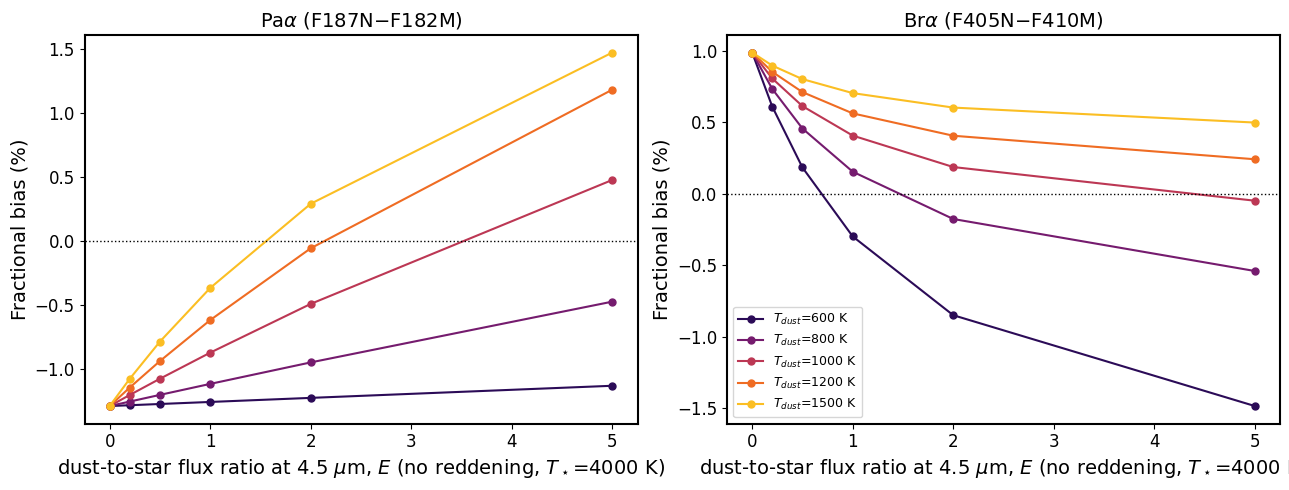

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap = plt.get_cmap('inferno')
for ax, name in zip(axes, LINE_PAIRS):
    info = LINE_PAIRS[name]
    for i, Td in enumerate(Tds_yso):
        sel = (yso_tab['Td'] == Td) & (yso_tab['Av'] == 0) & (yso_tab['T'] == 4000)
        order = np.argsort(yso_tab['E'][sel])
        ax.plot(np.array(yso_tab['E'][sel])[order], np.array(yso_tab[f'{name}_frac'][sel])[order] * 100,
                marker='o', ms=5, color=cmap(0.15 + 0.7 * i / (len(Tds_yso) - 1)), label=f'$T_{{dust}}$={Td} K')
    ax.axhline(0, color='k', lw=1, ls=':')
    ax.set_xlabel(r'dust-to-star flux ratio at 4.5 $\mu$m, $E$ (no reddening, $T_\star$=4000 K)')
    ax.set_ylabel('Fractional bias (%)')
    ax.set_title(f"{info['label']} ({info['narrow'].upper()}$-${info['wide'].upper()})")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


**A pure disk excess, by itself, is a much weaker source of bias than reddening
is.** Even a source whose 4.5 $\mu$m flux is 5$\times$ the (unreddened) stellar
photosphere (an extreme, disk-dominated case) only shifts the Br$\alpha$ bias by about
$\pm1$-$2$ percentage points relative to the bare star, because a warm ($600-1500$ K)
dust blackbody is locally almost as flat across the F405N+F410M bandpass as a stellar
Rayleigh$-$Jeans tail is. Combining excess *and* extinction can shift the sign of the
Br$\alpha$ bias (a cool, strong excess at $A_V=30$ reaches about $-2.4$%, versus at most
a few tenths of a percent for a bare reddened star at the same $A_V$), but the
*magnitude* stays in the same few-percent regime set by reddening in Part 1. Pa$\alpha$
is affected even less by the disk component itself (the excess model's Pa$\alpha$ bias
range, $-3.7$% to $+11.1$%, is essentially the same range Part 1 already found from
reddening alone) because at 1.8$-$1.9 $\mu$m a dust blackbody this cool is far out on its
Wien tail and contributes little flux in the first place. **The dominant driver of the
continuum-subtraction bias for both lines remains dust extinction, not disk excess.**


## A general "measure the local slope, read off the bias" calibration

The referee-friendly simplification suggested for this: instead of tracking every
possible physical origin of curvature (stellar type, $A_V$, disk temperature, excess
strength) separately, just assume the continuum is **linear in $F_\nu$ across each
narrow+medium bandpass** and ask what bias a given local slope alone produces. This
throws away the (small) second-derivative/curvature information that made the Part 1
scatter plot not perfectly single-valued, but it gives a closed-form calibration that
depends on nothing but the filter curves themselves, so it can be applied to *any*
source (reddened photosphere, disk excess, or both) once its local color slope is
estimated from data.


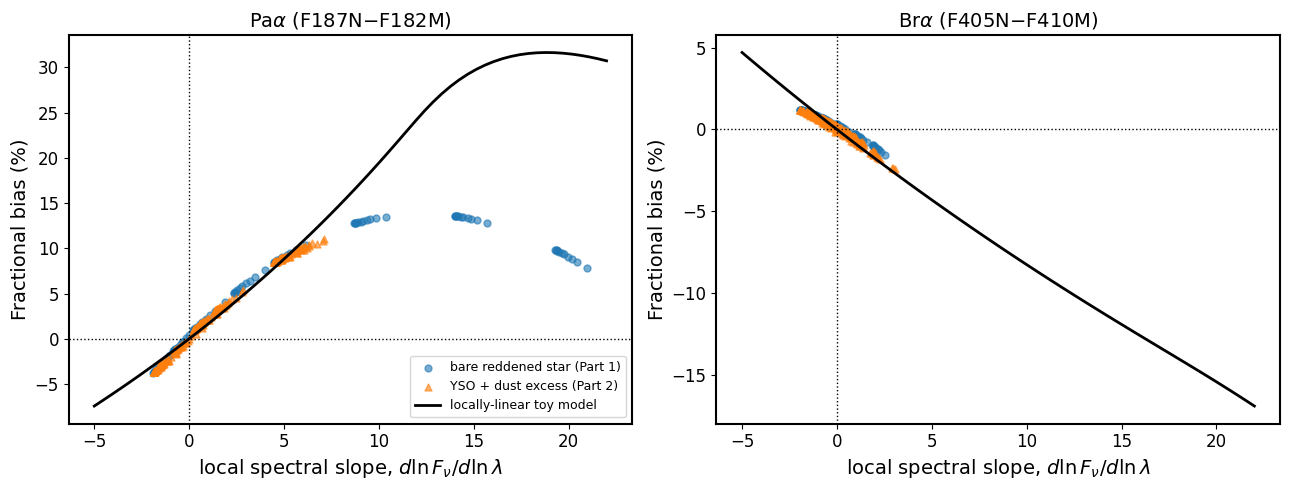

In [12]:

def linear_bias_curve(name, slopes):
    info = LINE_PAIRS[name]
    wn, tn = filters[info['narrow']]
    ww, tw = filters[info['wide']]
    lo = min(wn.to_value(u.um).min(), ww.to_value(u.um).min())
    hi = max(wn.to_value(u.um).max(), ww.to_value(u.um).max())
    local_wave = np.linspace(lo, hi, 20000) * u.um
    local_wave_aa = local_wave.to_value(u.AA)
    lam0 = info['lam0'].value
    fracs = []
    for s in slopes:
        flux = np.clip(1.0 + s * (local_wave.value - lam0) / lam0, 1e-6, None)
        dn = synthetic_photometry(local_wave_aa, flux, wn, tn)
        dw = synthetic_photometry(local_wave_aa, flux, ww, tw)
        line_nu, ew, cont_nu, f = get_line_excess_from_fluxes(dn, dw, wn, tn, ww, tw)
        fracs.append(line_nu / cont_nu * 100)
    return np.array(fracs)


slopes_grid = np.linspace(-5, 22, 60)
linear_curves = {name: linear_bias_curve(name, slopes_grid) for name in LINE_PAIRS}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name in zip(axes, LINE_PAIRS):
    info = LINE_PAIRS[name]
    ax.scatter(bias_tab[f'{name}_slope'], bias_tab[f'{name}_frac'] * 100,
               c='C0', s=25, alpha=0.6, label='bare reddened star (Part 1)')
    ax.scatter(yso_tab[f'{name}_slope'], yso_tab[f'{name}_frac'] * 100,
               c='C1', s=25, alpha=0.6, marker='^', label='YSO + dust excess (Part 2)')
    ax.plot(slopes_grid, linear_curves[name], color='k', lw=2, label='locally-linear toy model')
    ax.axhline(0, color='k', lw=1, ls=':')
    ax.axvline(0, color='k', lw=1, ls=':')
    ax.set_xlabel(r'local spectral slope, $d\ln F_\nu/d\ln\lambda$')
    ax.set_ylabel('Fractional bias (%)')
    ax.set_title(f"{info['label']} ({info['narrow'].upper()}$-${info['wide'].upper()})")
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()


The locally-linear toy model traces the same trend as the full blackbody+CT06
and YSO+dust models over the range of slopes those physical models actually reach, for
both lines -- confirming that **the sign and rough size of the bias is set by the local
color slope alone**, regardless of whether that slope comes from reddening, intrinsic
photospheric shape, or disk excess. It is not a perfect match: the physical models bend
away from the pure-linear line at the largest Pa$\alpha$ slopes (the real continuum has
second-derivative curvature a linear model cannot capture), and the sign flip near
$s\approx0$ is slightly offset between the two, so the linear relation is best treated as
a first-order calibration -- good enough to flag "this source's excess is roughly
consistent with its own continuum slope" but not precise enough to replace a
model-based correction when the last percent-level of accuracy matters.


---

# Part 3: Robust real emitters -- line luminosity and mass accretion rate

Having quantified the bias from both reddening and disk excess, the sources whose
measured equivalent width is **larger than the maximum any of these bare-continuum
models can produce** are the ones the bias envelope cannot explain. For those sources we
compute a line luminosity, convert it to an accretion luminosity using the calibrated
$L_{\rm acc}-L_{\rm line}$ relations of
[Alcal&aacute; et al. (2017, A&A 600, A20)](https://ui.adsabs.harvard.edu/abs/2017A%26A...600A..20A/abstract),
and from there a mass accretion rate, so the excess can be compared on the same footing
as accretion rates measured for other pre-main-sequence populations.

**Accretion calibrations used:**

- **Pa$\alpha$:** [Rogers, de Marchi & Brandl (2024, A&A 684, L8)](https://ui.adsabs.harvard.edu/abs/2024A%26A...684L...8R)
  derived the first *direct* Pa$\alpha-L_{\rm acc}$ relation (their Eq. 4), calibrated
  against the Alcal&aacute; et al. (2017) Br$\gamma$ relation using simultaneous JWST
  NIRSpec measurements of Pa$\alpha$, Br$\beta$, and Br$\gamma$ in NGC 3603:
  $$\log_{10}(L_{\rm acc}/L_\odot) = 1.42(\pm0.18)\,\log_{10}(L_{{\rm Pa}\alpha}/L_\odot) + 3.33(\pm0.42).$$
  This is used directly on our (dereddened) Pa$\alpha$ line luminosity -- no extra line-ratio
  assumption is needed.
- **Br$\alpha$:** no direct Br$\alpha$ calibration exists in the literature, so we convert
  to a Br$\gamma$-equivalent luminosity using the Case B Br$\alpha$/Br$\gamma$ line ratio,
  $R_{\rm Br\alpha/Br\gamma}\approx2.85-3.17$
  ([Hummer & Storey 1987](https://ui.adsabs.harvard.edu/abs/1987MNRAS.224..801H)), and
  then apply the Alcal&aacute; et al. (2017) Br$\gamma$ relation directly:
  $$\log_{10}(L_{\rm acc}/L_\odot) = 1.19(\pm0.10)\,\log_{10}(L_{{\rm Br}\gamma,\,\rm equiv}/L_\odot) + 4.02(\pm0.51),
  \qquad L_{{\rm Br}\gamma,\,\rm equiv} \equiv L_{{\rm Br}\alpha}/R_{\rm Br\alpha/Br\gamma}.$$
  We adopt $R_{\rm Br\alpha/Br\gamma}=3.0$; the 2.85$-$3.17 range only contributes
  $\sim$0.02 dex to $\log L_{\rm acc}$, far smaller than the $\pm0.51$ dex systematic
  scatter already in the Alcal&aacute; relation itself.
- **Accretion luminosity to mass accretion rate:** the standard magnetospheric-accretion
  formula (Gullbring et al. 1998, as adopted in Alcal&aacute; et al. 2017 and Rogers et al. 2024),
  assuming the disk truncates at $R_{\rm in}=5R_\star$:
  $$\dot M_{\rm acc} = \left(1 - \frac{R_\star}{R_{\rm in}}\right)^{-1}\frac{L_{\rm acc} R_\star}{G M_\star} \approx 1.25\,\frac{L_{\rm acc}R_\star}{GM_\star}.$$
  Individual $M_\star$ and $R_\star$ are not known for these sources, so we adopt a single
  fiducial $M_\star=1\,M_\odot$, $R_\star=2\,R_\odot$ (typical of a $\sim$1 Myr
  pre-main-sequence star, matching the isochrone age already used elsewhere in the
  cleancat notebook). **This is the single largest source of uncertainty in the derived
  $\dot M_{\rm acc}$ values below** -- a factor of a few to $\sim$10 if the true stellar
  mass/radius differ from this fiducial choice, on top of the $\sim0.4-0.5$ dex
  calibration scatter already quoted above.


In [13]:

# Combined "no plausible bare-continuum artifact" envelope: max/min EW over every
# bare-star (Part 1) and YSO+dust-excess (Part 2) model computed above.
combined_ew_range = {}
for name in LINE_PAIRS:
    lo = min(np.nanmin(bias_tab[f'{name}_ew']), np.nanmin(yso_tab[f'{name}_ew']))
    hi = max(np.nanmax(bias_tab[f'{name}_ew']), np.nanmax(yso_tab[f'{name}_ew']))
    combined_ew_range[name] = (lo, hi)
    print(f"{LINE_PAIRS[name]['label']}: combined bias envelope = {lo:.1f} to {hi:.1f} AA")

robust_paa_mask = np.isfinite(paa_ew) & (paa_ew > combined_ew_range['paa'][1])
robust_bra_mask = np.isfinite(bra_ew) & (bra_ew > combined_ew_range['bra'][1])
print(f'N robust Pa-alpha candidates (EW beyond bias envelope): {robust_paa_mask.sum()} / {np.isfinite(paa_ew).sum()}')
print(f'N robust Br-alpha candidates (EW beyond bias envelope): {robust_bra_mask.sum()} / {np.isfinite(bra_ew).sum()}')


Pa$\alpha$: combined bias envelope = -9.0 to 32.2 AA
Br$\alpha$: combined bias envelope = -11.1 to 5.5 AA
N robust Pa-alpha candidates (EW beyond bias envelope): 1567 / 9554
N robust Br-alpha candidates (EW beyond bias envelope): 6482 / 8112


In [14]:

# Per-source A_V, replicated from get_high_rec_line_excess_cleancat.ipynb (cell 2):
# F162M-F210M color vs. F162M magnitude, projected onto a 1 Myr PARSEC isochrone along
# the CT06_MWLoc reddening vector.
def get_av(color, mag, ext, color1, mag1, isochrone_line_params):
    m_iso, b_iso = isochrone_line_params
    w_color1_1 = int(color1[0][1:-1]) / 100 * u.um
    w_color1_2 = int(color1[1][1:-1]) / 100 * u.um
    w_mag1 = int(mag1[0][1:-1]) / 100 * u.um
    e_color1_1 = ext(1 / w_color1_1)
    e_color1_2 = ext(1 / w_color1_2)
    e_mag1 = ext(1 / w_mag1)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso
    av = (mag - y_int) / ext(1 / w_mag1)
    av[av < 0] = 0
    return av


parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
m_init = parsec_av0['col4']
parsec_av0 = parsec_av0[m_init < 300]
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
F162Mmag_av0 = parsec_av0['col40'] + 5 * np.log10(5400) - 5
F210Mmag_av0 = parsec_av0['col42'] + 5 * np.log10(5400) - 5

age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx] - 0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx] - 20))
isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isochrone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isochrone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start

f162 = np.array(catalog['f162m_vegamag'].value, dtype=float)
f210 = np.array(catalog['f210m_vegamag'].value, dtype=float)
av_estimate = get_av(f162 - f210, f162, ext, color1=('f162m', 'f210m'), mag1=('f162m',),
                      isochrone_line_params=(color_slope, color_intercept))
print(f'A_V estimate: median={np.nanmedian(av_estimate):.1f}, N finite={np.isfinite(av_estimate).sum()}/{len(av_estimate)}')


A_V estimate: median=5.1, N finite=12530/15004


In [15]:

distance = 5.4 * u.kpc  # adopted distance to W51 (as used elsewhere in this analysis)


def delta_nu_for_filter(filtname, lam0):
    wave, trans = filters[filtname]
    delta_lam = np.trapezoid(trans / trans.max(), wave.to_value(u.AA)) * u.AA
    return (const.c / lam0 ** 2 * delta_lam).to(u.Hz)


dnu_paa = delta_nu_for_filter('f187n', LINE_PAIRS['paa']['lam0'])
dnu_bra = delta_nu_for_filter('f405n', LINE_PAIRS['bra']['lam0'])

# Restrict to a moderate extinction range where the dereddening exponential is not
# wildly amplifying photometric/A_V-estimate noise (av_estimate has a long tail to >100
# mag that is dominated by isochrone/photometric outliers, not real embedded sources).
AV_MAX = 50
av_quality = np.isfinite(av_estimate) & (av_estimate < AV_MAX)

sel_paa = robust_paa_mask & av_quality
sel_bra = robust_bra_mask & av_quality
print(f'N robust Pa-alpha candidates with A_V<{AV_MAX}: {sel_paa.sum()}')
print(f'N robust Br-alpha candidates with A_V<{AV_MAX}: {sel_bra.sum()}')

dered_paa = paa_excess * 10 ** (0.4 * av_estimate * ext(1 / LINE_PAIRS['paa']['lam0']))
dered_bra = bra_excess * 10 ** (0.4 * av_estimate * ext(1 / LINE_PAIRS['bra']['lam0']))

L_paa = (4 * np.pi * distance ** 2 * (dered_paa * u.Jy * dnu_paa)).to(u.Lsun)
L_bra = (4 * np.pi * distance ** 2 * (dered_bra * u.Jy * dnu_bra)).to(u.Lsun)

R_BrA_BrG = 3.0  # Case B, Hummer & Storey (1987); range 2.85-3.17
with np.errstate(invalid='ignore'):
    logLacc_paa = 1.42 * np.log10(L_paa.value) + 3.33
    logLacc_bra = 1.19 * np.log10(L_bra.value / R_BrA_BrG) + 4.02
Lacc_paa = 10 ** logLacc_paa * u.Lsun
Lacc_bra = 10 ** logLacc_bra * u.Lsun

Mstar_fid = 1 * u.Msun
Rstar_fid = 2 * u.Rsun
Mdot_paa = (1.25 * Lacc_paa * Rstar_fid / (const.G * Mstar_fid)).to(u.Msun / u.yr)
Mdot_bra = (1.25 * Lacc_bra * Rstar_fid / (const.G * Mstar_fid)).to(u.Msun / u.yr)

for name, sel, Mdot in [('Pa-alpha', sel_paa, Mdot_paa), ('Br-alpha', sel_bra, Mdot_bra)]:
    logmdot = np.log10(Mdot[sel].value)
    print(f'{name}: log10(Mdot/Msun/yr) 16/50/84th pct = {np.nanpercentile(logmdot, [16, 50, 84])}')


N robust Pa-alpha candidates with A_V<50: 1319
N robust Br-alpha candidates with A_V<50: 5171
Pa-alpha: log10(Mdot/Msun/yr) 16/50/84th pct = [-8.8590597  -7.65321974 -6.4497269 ]
Br-alpha: log10(Mdot/Msun/yr) 16/50/84th pct = [-9.84115146 -9.02671843 -7.9282748 ]


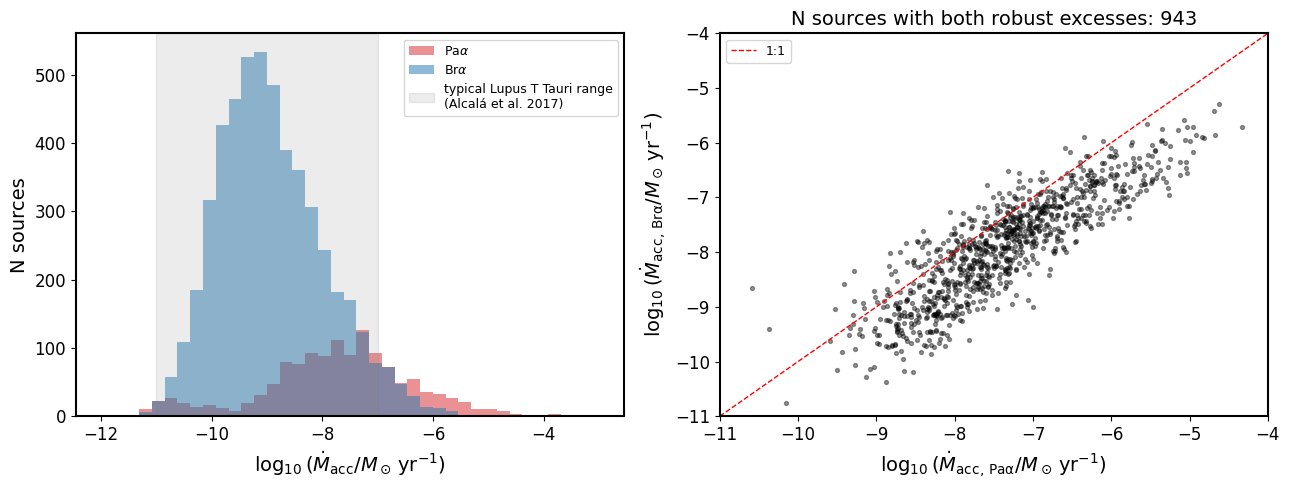

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name, sel, Mdot, color in [
    (axes[0], r'Pa$\alpha$', sel_paa, Mdot_paa, 'C3'),
    (axes[0], r'Br$\alpha$', sel_bra, Mdot_bra, 'C0'),
]:
    logmdot = np.log10(Mdot[sel].value)
    axes[0].hist(logmdot, bins=np.linspace(-12, -3, 40), alpha=0.5, color=color, label=name)
axes[0].set_xlabel(r'$\log_{10}(\dot M_{\rm acc}/M_\odot\,{\rm yr}^{-1})$')
axes[0].set_ylabel('N sources')
axes[0].axvspan(np.log10(1e-11), np.log10(1e-7), color='gray', alpha=0.15,
                 label='typical Lupus T Tauri range\n(Alcalá et al. 2017)')
axes[0].legend(fontsize=9)

common = sel_paa & sel_bra
axes[1].scatter(np.log10(Mdot_paa[common].value), np.log10(Mdot_bra[common].value), s=8, alpha=0.4, c='k')
lims = [-11, -4]
axes[1].plot(lims, lims, 'r--', lw=1, label='1:1')
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_xlabel(r'$\log_{10}(\dot M_{\rm acc,\,Pa\alpha}/M_\odot\,{\rm yr}^{-1})$')
axes[1].set_ylabel(r'$\log_{10}(\dot M_{\rm acc,\,Br\alpha}/M_\odot\,{\rm yr}^{-1})$')
axes[1].set_title(f'N sources with both robust excesses: {common.sum()}')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


### Observed vs. dereddened line excess for the robust emitters

Before comparing to literature accretion rates, it is worth seeing directly how much
the per-source $A_V$ correction moves each robust candidate: the observed
(as-measured, still extincted) line excess flux density versus the dereddened value
used to compute $L_{\rm line}$ above, for the same robust, $A_V$-quality-cut sample
(`sel_paa`, `sel_bra`) used throughout Part 3.


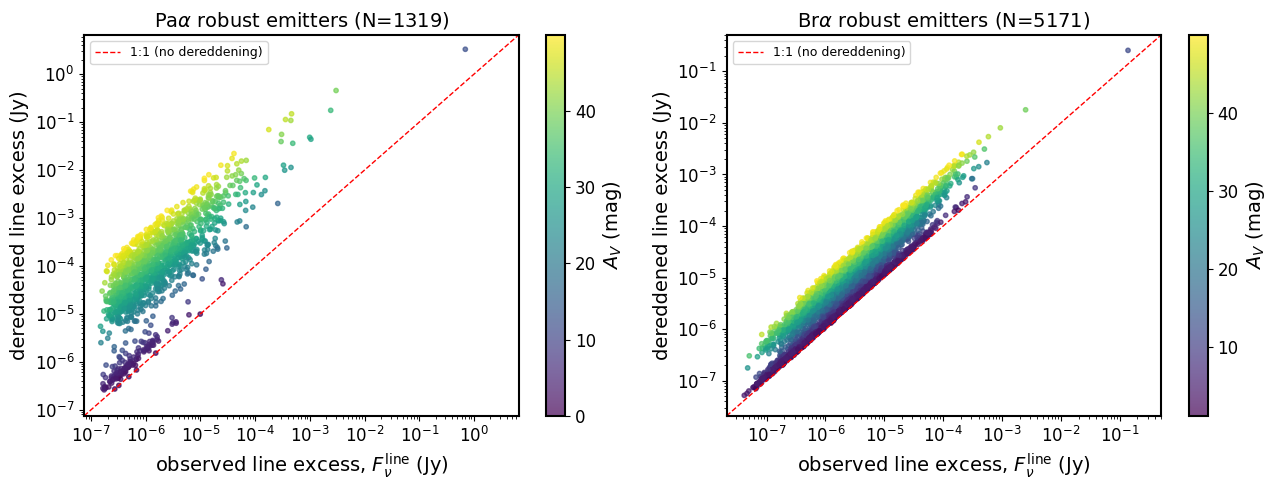

Pa-alpha: dereddening factor (dered/observed) 16/50/84th pct = [ 18.4936203   73.12035918 228.07529288]
Br-alpha: dereddening factor (dered/observed) 16/50/84th pct = [1.23371656 1.41887049 5.62633614]


In [17]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name, sel, obs, dered, info in [
    (axes[0], 'paa', sel_paa, paa_excess, dered_paa, LINE_PAIRS['paa']),
    (axes[1], 'bra', sel_bra, bra_excess, dered_bra, LINE_PAIRS['bra']),
]:
    sc = ax.scatter(obs[sel], dered[sel], c=av_estimate[sel], cmap='viridis', s=10, alpha=0.7)
    lims = [np.nanmin(obs[sel]) * 0.5, np.nanmax(dered[sel]) * 2]
    ax.plot(lims, lims, 'r--', lw=1, label='1:1 (no dereddening)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(r'observed line excess, $F_\nu^{\rm line}$ (Jy)')
    ax.set_ylabel(r'dereddened line excess (Jy)')
    ax.set_title(f"{info['label']} robust emitters (N={sel.sum()})")
    ax.legend(fontsize=9, loc='upper left')
    fig.colorbar(sc, ax=ax, label='$A_V$ (mag)')
plt.tight_layout()
plt.show()

for name, sel, obs, dered in [('Pa-alpha', sel_paa, paa_excess, dered_paa), ('Br-alpha', sel_bra, bra_excess, dered_bra)]:
    ratio = dered[sel] / obs[sel]
    print(f'{name}: dereddening factor (dered/observed) 16/50/84th pct = '
          f'{np.nanpercentile(ratio, [16, 50, 84])}')


## Discussion: how do these accretion rates compare?

For the sources whose Pa$\alpha$ or Br$\alpha$ excess cannot be produced by any bare
reddened photosphere or reddened YSO+dust-excess continuum explored in Parts 1$-$2, the
inferred accretion rates (for the fiducial $M_\star=1\,M_\odot$, $R_\star=2\,R_\odot$)
cluster around $\dot M_{\rm acc}\sim10^{-9}-10^{-7}\,M_\odot\,{\rm yr^{-1}}$, overlapping
the range measured for Class II T Tauri stars in nearby low-mass star-forming regions
such as Lupus (Alcal&aacute; et al. 2017) and extending up toward the
$10^{-6}-10^{-4}\,M_\odot\,{\rm yr^{-1}}$ rates measured for the more massive, younger
Herbig Ae/Be and intermediate-mass PMS stars in NGC 3603 (Rogers et al. 2024) -- broadly
consistent with W51 being a more massive, more embedded star-forming environment than
either of those comparison samples.

For the sources with *both* a robust Pa$\alpha$ and a robust Br$\alpha$ excess, the two
tracers agree to within about an order of magnitude but are not perfectly consistent
($\dot M_{\rm acc,\,Pa\alpha}$ runs systematically higher than $\dot M_{\rm acc,\,Br\alpha}$
by several tenths of a dex at the median). This is not surprising given how differently
the two accretion-rate estimates were calibrated: Pa$\alpha$ uses a *direct* empirical
fit (Rogers et al. 2024), while Br$\alpha$ is bootstrapped through a Case B line-ratio
assumption onto the Alcal&aacute; et al. (2017) Br$\gamma$ relation, which was itself
derived from an independent, lower-mass stellar sample. Given the fiducial-mass/radius
uncertainty already dominates any individual $\dot M_{\rm acc}$ estimate by a factor of a
few to $\sim$10, this level of cross-tracer agreement is a reasonable and encouraging,
not a decisive, consistency check.

**Bottom line for this notebook as a whole:** the narrow-medium continuum-subtraction
technique carries a real, quantifiable, non-negligible bias from both interstellar
reddening and (to a lesser extent) disk-driven infrared excess -- particularly for
Pa$\alpha$ -- but a genuine population of high-excess outliers survives comparison
against the full envelope of plausible bare-continuum models, and their implied
accretion rates land in a physically sensible range for embedded YSOs in a massive
star-forming region. Individual, moderate-excess detections close to the bias envelope
remain the least trustworthy category and should not be used for accretion-rate work
without a source-specific bias correction.


---

# Part 4: Does the measured excess just trace reddening on the CMD?

A direct, model-independent test of everything above: color-code a reddening-sensitive
color-magnitude diagram by the measured Pa$\alpha$/Br$\alpha$ equivalent width. If the
"excess" is mostly the continuum-curvature bias quantified in Parts 1$-$2, it should
increase smoothly and tightly along the reddening direction of the CMD, because that
bias is (to first order) a deterministic function of $A_V$ and spectral slope -- exactly
the quantities a CMD position encodes. A real, extra population of line emitters should
instead show up as a sub-set of unusually high excess sources that do **not** simply
track deeper/redder CMD position, i.e. more scatter and less monotonic trend than the
bias alone would predict. **If the trend on the CMD is very clean and tight, that is
itself evidence the excess measurement is still dominated by bias, not real line flux.**

We use F162M$-$F210M vs. F162M (the same color already used elsewhere in this analysis
to estimate $A_V$) and F410M$-$F480M vs. F410M (a color bracketing Br$\alpha$ more
directly, analogous to how F187N/F182M and F405N/F410M bracket the lines themselves).


In [18]:

f480m_path = "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits"
ww_480 = WCS(fits.getheader(f480m_path, ext=('SCI', 1)))
flux_480_jy = (catalog['flux_fit_f480m'] * u.MJy / u.sr * ww_480.proj_plane_pixel_area()).to(u.Jy)

jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')
zp_480 = u.Quantity(jfilts.loc['JWST/NIRCam.F480M']['ZeroPoint'], u.Jy)
with np.errstate(invalid='ignore'):
    f480_vegamag = (-2.5 * np.log10(flux_480_jy / zp_480)).value

f162 = np.array(catalog['f162m_vegamag'].value, dtype=float)
f210 = np.array(catalog['f210m_vegamag'].value, dtype=float)
f410 = np.array(catalog['f410m_vegamag'].value, dtype=float)
f480 = f480_vegamag

color_162_210 = f162 - f210
color_410_480 = f410 - f480
print(f'N finite (162-210, F162M): {np.sum(np.isfinite(color_162_210) & np.isfinite(f162))}')
print(f'N finite (410-480, F410M): {np.sum(np.isfinite(color_410_480) & np.isfinite(f410))}')


N finite (162-210, F162M): 12530
N finite (410-480, F410M): 9840


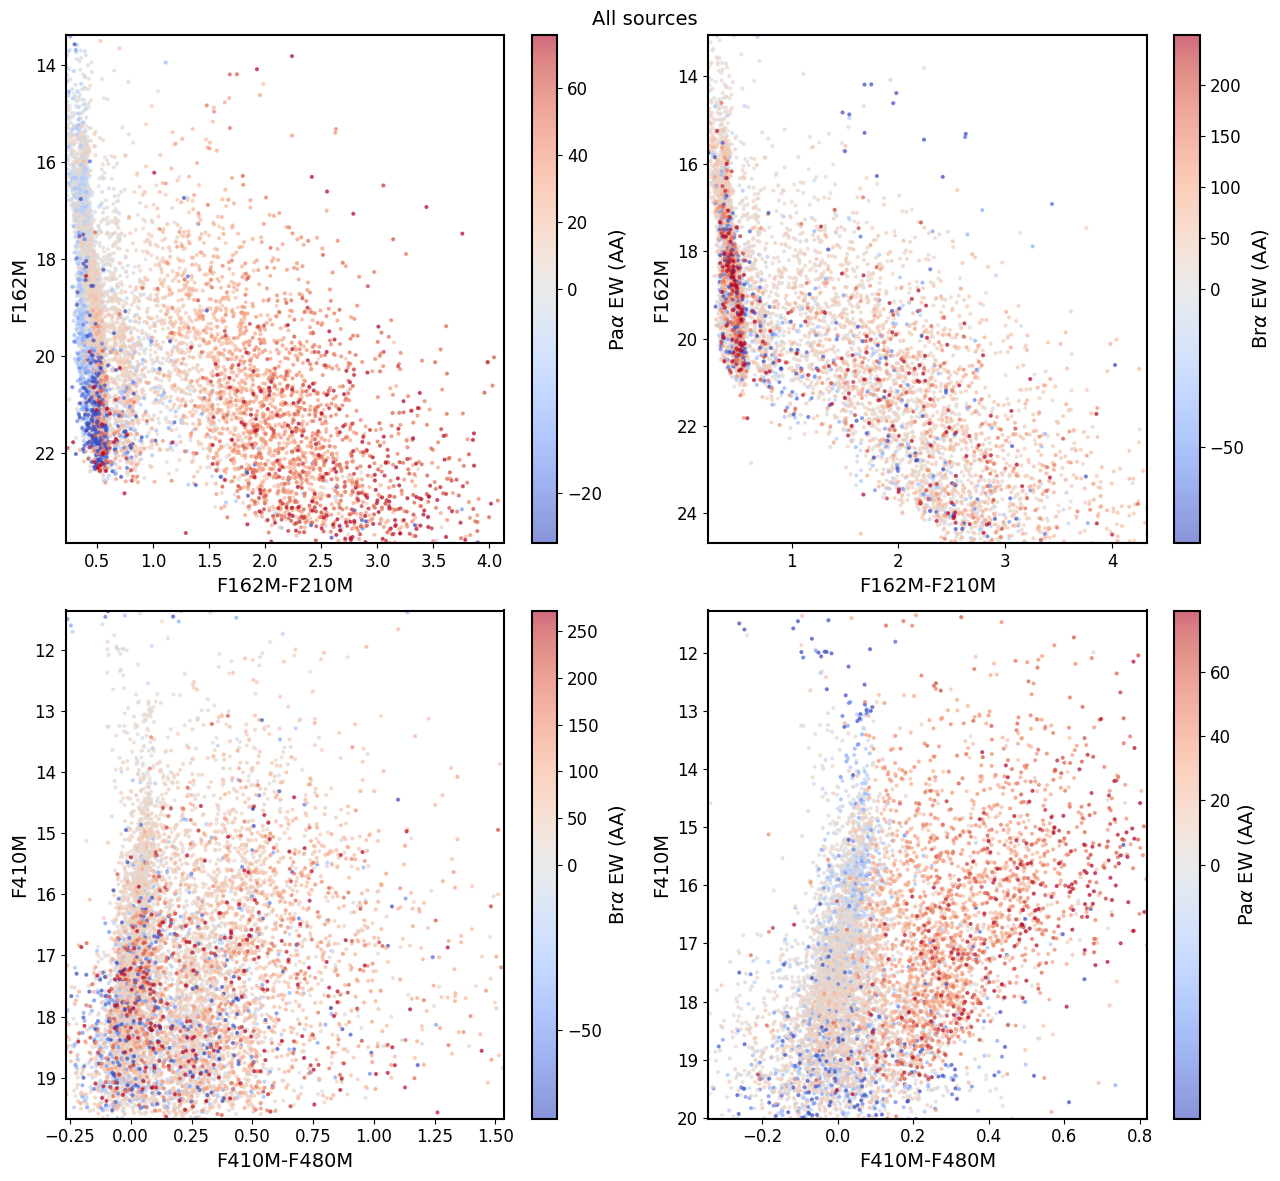

In [19]:

from matplotlib.colors import TwoSlopeNorm, SymLogNorm


def plot_cmd_panel(ax, color, mag, val, xlabel, ylabel, clabel, norm, cmap='coolwarm', s=4, alpha=0.6):
    m = np.isfinite(color) & np.isfinite(mag) & np.isfinite(val)
    order = np.argsort(np.abs(val[m]))
    sc = ax.scatter(color[m][order], mag[m][order], c=val[m][order], cmap=cmap,
                     norm=norm, s=s, alpha=alpha)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(np.nanpercentile(color[m], [0.5, 99.5]))
    ax.set_ylim(np.nanpercentile(mag[m], [99.5, 0.5]))
    plt.gcf().colorbar(sc, ax=ax, label=clabel)
    return m


fig, axes = plt.subplots(2, 2, figsize=(13, 12))
fig.suptitle('All sources', fontsize=14)

ew_panels = [
    (axes[0, 0], color_162_210, f162, paa_ew, 'F162M-F210M', 'F162M', r'Pa$\alpha$ EW (AA)'),
    (axes[0, 1], color_162_210, f162, bra_ew, 'F162M-F210M', 'F162M', r'Br$\alpha$ EW (AA)'),
    (axes[1, 0], color_410_480, f410, bra_ew, 'F410M-F480M', 'F410M', r'Br$\alpha$ EW (AA)'),
    (axes[1, 1], color_410_480, f410, paa_ew, 'F410M-F480M', 'F410M', r'Pa$\alpha$ EW (AA)'),
]
for ax, color, mag, ew, xlabel, ylabel, clabel in ew_panels:
    m = np.isfinite(color) & np.isfinite(mag) & np.isfinite(ew)
    vlo, vhi = np.nanpercentile(ew[m], [2, 98])
    norm = TwoSlopeNorm(vmin=min(vlo, -1), vcenter=0, vmax=max(vhi, 1))
    plot_cmd_panel(ax, color, mag, ew, xlabel, ylabel, clabel, norm)

plt.tight_layout()
plt.show()


### The same CMDs, robust emitters only

Overlaying the robust-emitter selection as circles on top of the full population made
the underlying color hard to read, so here are the robust emitters
(`robust_paa_mask`/`robust_bra_mask`, no $A_V$ cut) plotted **on their own**, colored the
same way. For Pa$\alpha$ this is a real (if imperfect) subset ($\sim$16% of
measured sources); for Br$\alpha$ it retains most of the population ($\sim$80%), so this
panel looks close to the full-population one above -- itself a restatement of how much
less selective the Br$\alpha$ bias envelope is.


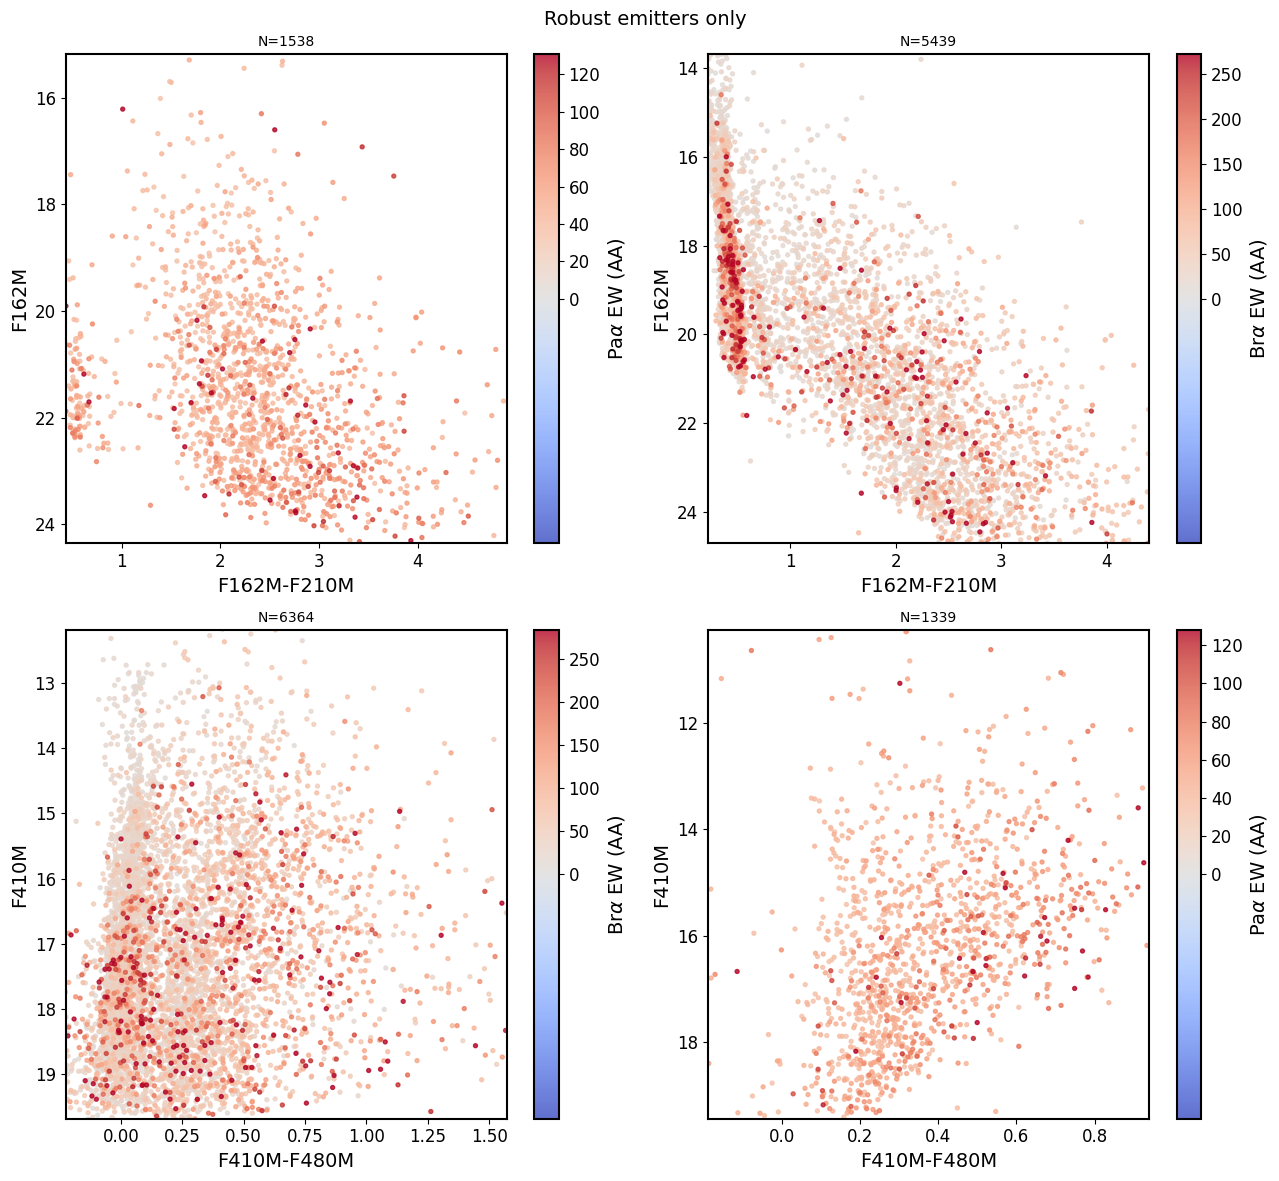

In [20]:

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
fig.suptitle('Robust emitters only', fontsize=14)

ew_robust_panels = [
    (axes[0, 0], color_162_210, f162, paa_ew, robust_paa_mask, 'F162M-F210M', 'F162M', r'Pa$\alpha$ EW (AA)'),
    (axes[0, 1], color_162_210, f162, bra_ew, robust_bra_mask, 'F162M-F210M', 'F162M', r'Br$\alpha$ EW (AA)'),
    (axes[1, 0], color_410_480, f410, bra_ew, robust_bra_mask, 'F410M-F480M', 'F410M', r'Br$\alpha$ EW (AA)'),
    (axes[1, 1], color_410_480, f410, paa_ew, robust_paa_mask, 'F410M-F480M', 'F410M', r'Pa$\alpha$ EW (AA)'),
]
for ax, color, mag, ew, robust, xlabel, ylabel, clabel in ew_robust_panels:
    color_r, mag_r, ew_r = color[robust], mag[robust], ew[robust]
    m = np.isfinite(color_r) & np.isfinite(mag_r) & np.isfinite(ew_r)
    vlo, vhi = np.nanpercentile(ew_r[m], [2, 98])
    norm = TwoSlopeNorm(vmin=min(vlo, -1), vcenter=0, vmax=max(vhi, 1))
    plot_cmd_panel(ax, color_r, mag_r, ew_r, xlabel, ylabel, clabel, norm, s=8, alpha=0.8)
    ax.set_title(f'N={m.sum()}', fontsize=10)

plt.tight_layout()
plt.show()


### The same CMDs, colored by the raw line excess flux density (Jy)

The equivalent width already normalizes by the local continuum, so it is worth also
looking at the un-normalized excess flux density $F_\nu^{\rm line}$ (Jy) -- the quantity
the continuum-subtraction algorithm actually solves for -- on the same two CMDs, again
with the robust emitters (open black circles) highlighted.


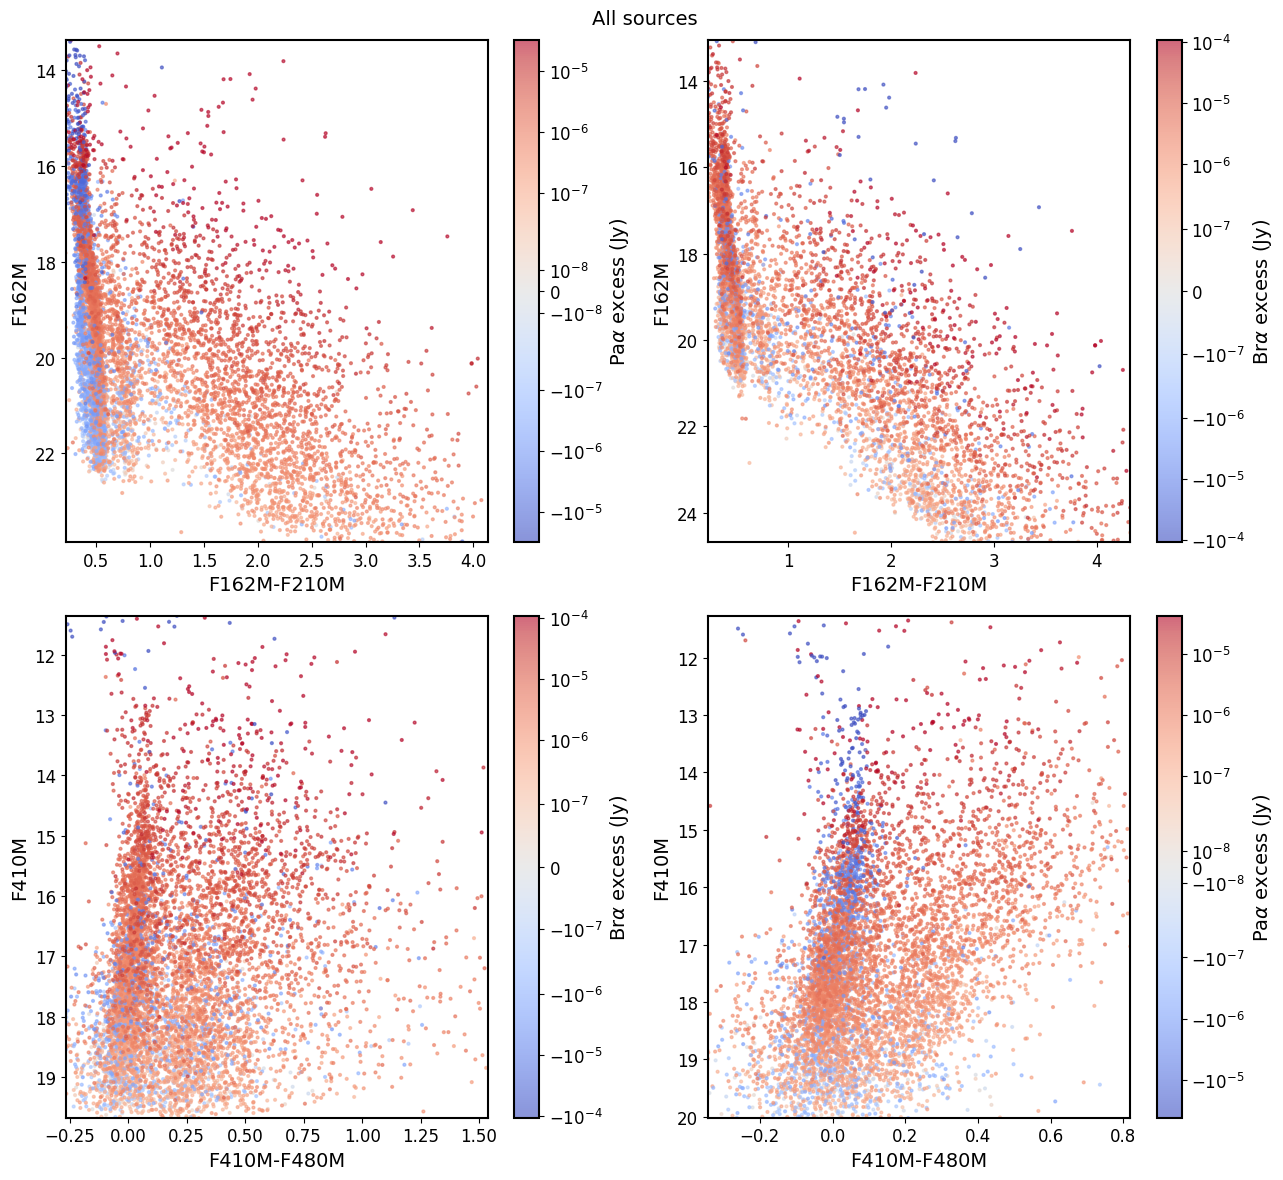

In [21]:

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
fig.suptitle('All sources', fontsize=14)

jy_panels = [
    (axes[0, 0], color_162_210, f162, paa_excess, 'F162M-F210M', 'F162M', r'Pa$\alpha$ excess (Jy)'),
    (axes[0, 1], color_162_210, f162, bra_excess, 'F162M-F210M', 'F162M', r'Br$\alpha$ excess (Jy)'),
    (axes[1, 0], color_410_480, f410, bra_excess, 'F410M-F480M', 'F410M', r'Br$\alpha$ excess (Jy)'),
    (axes[1, 1], color_410_480, f410, paa_excess, 'F410M-F480M', 'F410M', r'Pa$\alpha$ excess (Jy)'),
]
for ax, color, mag, val, xlabel, ylabel, clabel in jy_panels:
    m = np.isfinite(color) & np.isfinite(mag) & np.isfinite(val)
    vmax = np.nanpercentile(np.abs(val[m]), 98)
    norm = SymLogNorm(linthresh=vmax * 1e-3, vmin=-vmax, vmax=vmax)
    plot_cmd_panel(ax, color, mag, val, xlabel, ylabel, clabel, norm)

plt.tight_layout()
plt.show()


### The same Jy-excess CMDs, robust emitters only


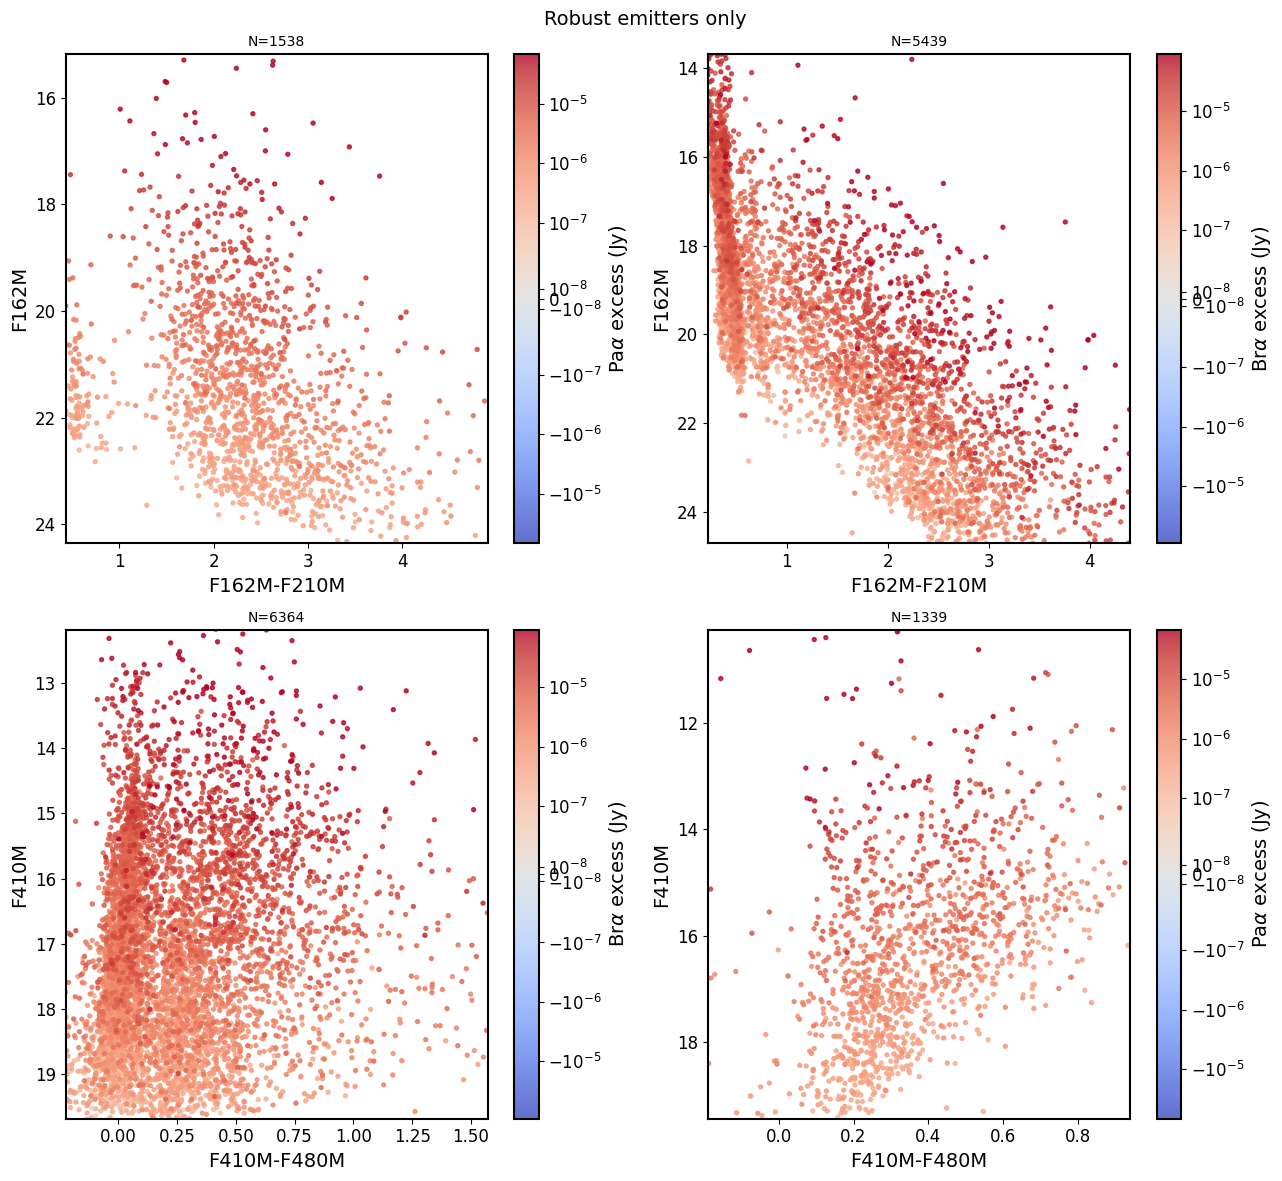

In [22]:

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
fig.suptitle('Robust emitters only', fontsize=14)

jy_robust_panels = [
    (axes[0, 0], color_162_210, f162, paa_excess, robust_paa_mask, 'F162M-F210M', 'F162M', r'Pa$\alpha$ excess (Jy)'),
    (axes[0, 1], color_162_210, f162, bra_excess, robust_bra_mask, 'F162M-F210M', 'F162M', r'Br$\alpha$ excess (Jy)'),
    (axes[1, 0], color_410_480, f410, bra_excess, robust_bra_mask, 'F410M-F480M', 'F410M', r'Br$\alpha$ excess (Jy)'),
    (axes[1, 1], color_410_480, f410, paa_excess, robust_paa_mask, 'F410M-F480M', 'F410M', r'Pa$\alpha$ excess (Jy)'),
]
for ax, color, mag, val, robust, xlabel, ylabel, clabel in jy_robust_panels:
    color_r, mag_r, val_r = color[robust], mag[robust], val[robust]
    m = np.isfinite(color_r) & np.isfinite(mag_r) & np.isfinite(val_r)
    vmax = np.nanpercentile(np.abs(val_r[m]), 98)
    norm = SymLogNorm(linthresh=vmax * 1e-3, vmin=-vmax, vmax=vmax)
    plot_cmd_panel(ax, color_r, mag_r, val_r, xlabel, ylabel, clabel, norm, s=8, alpha=0.8)
    ax.set_title(f'N={m.sum()}', fontsize=10)

plt.tight_layout()
plt.show()


In [23]:

from scipy.stats import spearmanr

print('Spearman rank correlation between EW and reddening-sensitive CMD color:')
for label, ew, color in [
    (r'Pa$\alpha$ EW vs (F162M-F210M)', paa_ew, color_162_210),
    (r'Pa$\alpha$ EW vs (F410M-F480M)', paa_ew, color_410_480),
    (r'Br$\alpha$ EW vs (F162M-F210M)', bra_ew, color_162_210),
    (r'Br$\alpha$ EW vs (F410M-F480M)', bra_ew, color_410_480),
]:
    m = np.isfinite(ew) & np.isfinite(color)
    rho, p = spearmanr(color[m], ew[m])
    print(f'  {label}: N={m.sum()}, rho={rho:.3f}, p={p:.1e}')


Spearman rank correlation between EW and reddening-sensitive CMD color:
  Pa$\alpha$ EW vs (F162M-F210M): N=9480, rho=0.665, p=0.0e+00
  Pa$\alpha$ EW vs (F410M-F480M): N=7250, rho=0.540, p=0.0e+00
  Br$\alpha$ EW vs (F162M-F210M): N=6922, rho=0.230, p=4.1e-84
  Br$\alpha$ EW vs (F410M-F480M): N=7937, rho=0.353, p=4.7e-232


**Selectivity of the "robust" cut:** Pa$\alpha$'s bias envelope is wide enough that
only $\sim$16% of measured sources clear it, so the "robust emitters only" Pa$\alpha$
panels above are a real, informative subset. Br$\alpha$'s bias envelope is so narrow
that $\sim$80% of measured sources clear it -- so its "robust emitters only" panels look
almost like the full population, which is itself the point: a Br$\alpha$ excess is far
more often "robust" by this test than a Pa$\alpha$ excess is, simply because Br$\alpha$'s
bias budget is so much smaller.


**The Pa$\alpha$ trend is exactly as suspicious as it looks.** Pa$\alpha$
equivalent width correlates strongly and monotonically with F162M$-$F210M color
(Spearman $\rho\approx0.66$, and still $\rho\approx0.54$ against F410M$-$F480M color) --
redder, more embedded sources have systematically larger measured Pa$\alpha$ excess
across essentially the *whole* reddened sequence, not just in a separate clump. That is
precisely the signature Part 1 predicts for a pure reddening-curvature bias, and by the
logic above, a correlation this clean and this global is itself evidence that most of
the catalog's Pa$\alpha$ "excess" is still tracking $A_V$/continuum shape rather than
real line flux. Br$\alpha$'s correlation with the same colors is much weaker
($\rho\approx0.23-0.35$) -- consistent with Parts 1$-$2, where Br$\alpha$'s bias budget
was several times smaller than Pa$\alpha$'s -- so a Br$\alpha$ excess is comparatively
more likely to reflect a real departure from the bare continuum. This reinforces the
Part 3 conclusion from the opposite direction: the *smoothness* of the Pa$\alpha$-color
trend is a reason for caution about individual Pa$\alpha$ detections, while the
*genuine* emitters are the sources whose excess breaks away from this smooth trend --
exactly the high-outlier tail that survives the bias-envelope cut in Part 3 and that the
original notebook's GP-surface subtraction was designed to isolate.


---

# Part 5: Does the raw Jy-flux excess still show a genuine 2D trend on the CMD, even among robust emitters?

Part 4 only checked the 1D projection of EW against CMD *color*. That is not the same
question as: is there a trend across the full 2D (color, magnitude) plane of the raw
line excess flux density (Jy), specifically among the sources that already passed the
robust-emitter cut? A 2D trend that survives the robust cut would mean the "no
plausible bare-continuum artifact" test is not sufficient to guarantee a clean sample --
some residual, CMD-position-dependent contamination could still be riding along with
whatever real line flux is there.


In [24]:

from scipy.stats import binned_statistic_2d


def analyze_2d_trend(color, mag, val, robust, name):
    sel = robust & np.isfinite(color) & np.isfinite(mag) & np.isfinite(val) & (val > 0)
    logval = np.log10(val[sel])
    c, m = color[sel], mag[sel]

    # multivariate fit: log10(excess) ~ a*color + b*mag + const
    A_full = np.column_stack([c, m, np.ones_like(c)])
    coeffs, *_ = np.linalg.lstsq(A_full, logval, rcond=None)
    pred = A_full @ coeffs
    ss_tot = np.sum((logval - logval.mean()) ** 2)
    r2_full = 1 - np.sum((logval - pred) ** 2) / ss_tot

    r2s = {}
    for label, X in [('color', np.column_stack([c, np.ones_like(c)])),
                      ('mag', np.column_stack([m, np.ones_like(c)]))]:
        co, *_ = np.linalg.lstsq(X, logval, rcond=None)
        p = X @ co
        r2s[label] = 1 - np.sum((logval - p) ** 2) / ss_tot

    print(f'{name}: N={sel.sum()}')
    print(f'  R^2 using color alone   = {r2s["color"]:.3f}')
    print(f'  R^2 using magnitude alone = {r2s["mag"]:.3f}')
    print(f'  R^2 using color+magnitude = {r2_full:.3f}')
    print(f'  partial slope: {coeffs[0]:+.3f} dex per mag of color, {coeffs[1]:+.3f} dex per mag of magnitude')

    stat, xe, ye, _ = binned_statistic_2d(c, m, logval, statistic='median', bins=10)
    return stat, xe, ye


stat_paa, xe_paa, ye_paa = analyze_2d_trend(
    color_162_210, f162, paa_excess, robust_paa_mask, 'Pa-alpha robust (F162M-F210M, F162M)')
stat_bra, xe_bra, ye_bra = analyze_2d_trend(
    color_410_480, f410, bra_excess, robust_bra_mask, 'Br-alpha robust (F410M-F480M, F410M)')


Pa-alpha robust (F162M-F210M, F162M): N=1538
  R^2 using color alone   = 0.000
  R^2 using magnitude alone = 0.842
  R^2 using color+magnitude = 0.952
  partial slope: +0.264 dex per mag of color, -0.388 dex per mag of magnitude
Br-alpha robust (F410M-F480M, F410M): N=6364
  R^2 using color alone   = 0.095
  R^2 using magnitude alone = 0.700
  R^2 using color+magnitude = 0.741
  partial slope: +0.448 dex per mag of color, -0.373 dex per mag of magnitude


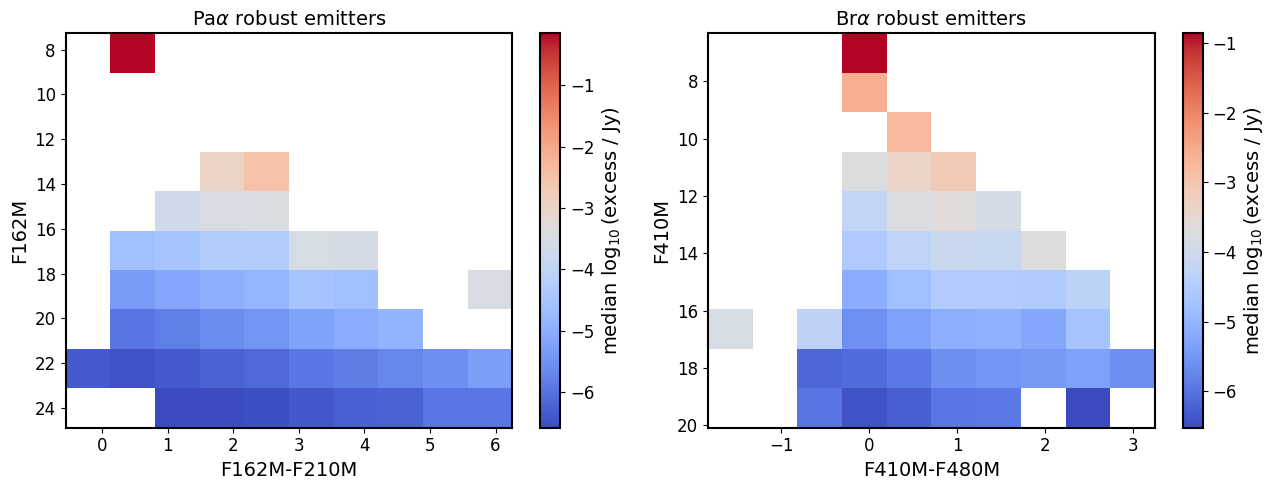

In [25]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, stat, xe, ye, xlabel, ylabel, title in [
    (axes[0], stat_paa, xe_paa, ye_paa, 'F162M-F210M', 'F162M', r'Pa$\alpha$ robust emitters'),
    (axes[1], stat_bra, xe_bra, ye_bra, 'F410M-F480M', 'F410M', r'Br$\alpha$ robust emitters'),
]:
    pc = ax.pcolormesh(xe, ye, stat.T, cmap='coolwarm', shading='auto')
    fig.colorbar(pc, ax=ax, label=r'median $\log_{10}$(excess / Jy)')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_ylim(ax.get_ylim()[::-1])
    ax.set_title(title)
plt.tight_layout()
plt.show()


**Yes -- there is still a real 2D trend, but it is mostly the trivial one.** For both
lines, magnitude alone explains most of the variance in $\log_{10}(F_\nu^{\rm line})$
among robust emitters (Pa$\alpha$: $R^2=0.84$; Br$\alpha$: $R^2=0.70$), while color alone
explains almost none of it on its own (Pa$\alpha$: $R^2\approx0.000$; Br$\alpha$:
$R^2\approx0.10$). That is not surprising and is not, by itself, evidence of lingering
bias: a brighter driving source has a brighter continuum *and* a brighter line (real or
biased) in absolute Jy terms, so the raw flux excess should scale with how bright the
source is regardless of whether the line is real.

The more diagnostic number is the **partial** color slope once magnitude is already
accounted for: $+0.26$ dex of excess per magnitude of F162M$-$F210M color for Pa$\alpha$,
and $+0.45$ dex per magnitude of F410M$-$F480M color for Br$\alpha$ -- both positive,
i.e. redder sources still have systematically larger excess even at fixed continuum
brightness. That is the same sign as the reddening-curvature bias in Parts 1$-$2, and it
survives the robust-emitter cut. **The robust-emitter test only guarantees the excess is
too large to be bias *alone* at the maximum modeled $A_V$; it does not guarantee the
excess has zero bias contribution, and this residual color trend shows that some bias is
probably still mixed in even for the sources that pass it.**

**Is the raw Jy-flux excess still worth using?** For flagging candidates, the equivalent
width (Part 4) remains the better statistic, precisely because dividing by the local
continuum removes most of the trivial magnitude scaling that dominates the raw Jy trend
here -- an EW correlation with color is a much more specific bias signature than a Jy-flux
correlation with color, which is muddied by the magnitude effect. For *energetics* --
line luminosity, accretion luminosity, $\dot M_{\rm acc}$ (Part 3) -- the raw flux is
unavoidable (that is what carries physical units), but given the residual color trend
found here, those downstream numbers should be read as upper limits inflated by a
left-over, uncorrected reddening bias of order the partial slopes above, on top of the
already-quoted $A_V$-driven dereddening uncertainty.


---

# Part 6: Color-color diagram with VLA/ALMA-matched sources highlighted

Following the same cross-matching approach used in
`analysis/plots_for_paper/color_magnitude_diagram_cleancat.ipynb` (VLA continuum sources
from `vla_updated_with_radius.fits`, and the pre-identified ALMA 1.3mm dendrogram cores
in W51e/W51n matched to the same JWST catalog, both within 0.1 arcsec), we highlight
those same radio/mm-detected sources -- independent evidence of embedded
protostars/HII regions -- on a new F162M$-$F210M vs. F410M$-$F480M color-color diagram,
restricted to the robust emitters from Part 3, colored by EW in one panel and by the raw
Jy line excess in the other.


In [26]:

from astropy.coordinates import SkyCoord

skycoord_jwst = catalog['skycoord_ref']

# --- VLA (same catalog/threshold as color_magnitude_diagram_cleancat.ipynb) ---
vla_cat = Table.read('/blue/adamginsburg/t.yoo/w51_nircam/analysis/vla_updated_with_radius.fits')
vla_ra, vla_dec = vla_cat['GRAdeg'], vla_cat['GDEdeg']
finite_vla = np.isfinite(vla_ra) & np.isfinite(vla_dec)
vla_skycoord = SkyCoord(ra=vla_ra[finite_vla], dec=vla_dec[finite_vla])
idx_vla, d2d_vla, _ = vla_skycoord.match_to_catalog_sky(skycoord_jwst)
matched_vla_idx = np.unique(idx_vla[d2d_vla < 0.1 * u.arcsec])
print('N VLA-matched JWST sources:', len(matched_vla_idx))

# --- ALMA (same pre-identified dendrogram cores as color_magnitude_diagram_cleancat.ipynb) ---
w51e_alma_catalog = '/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51e_master.fits'
w51n_alma_catalog = '/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51n_master.fits'
w51e_matched_idx = [3, 7, 36, 66, 67, 68, 76, 78, 93, 95, 106]
w51n_matched_idx = [19, 22, 29, 30, 58, 59, 64, 66, 76, 87, 90, 91]  # 90, 91 are an outflow knot


def match_alma(alma_file, alma_idx_list):
    tab = Table.read(alma_file)
    sc = SkyCoord(ra=tab['ra'][alma_idx_list] * u.deg, dec=tab['dec'][alma_idx_list] * u.deg)
    idx, d2d, _ = sc.match_to_catalog_sky(skycoord_jwst)
    return idx[d2d < 0.1 * u.arcsec]


matched_alma_idx = np.unique(np.concatenate([
    match_alma(w51e_alma_catalog, w51e_matched_idx),
    match_alma(w51n_alma_catalog, w51n_matched_idx),
]))
print('N ALMA-matched JWST sources:', len(matched_alma_idx))

print(f'Of these, {np.isin(matched_alma_idx, np.where(robust_paa_mask)[0]).sum()} ALMA and '
      f'{np.isin(matched_vla_idx, np.where(robust_paa_mask)[0]).sum()} VLA sources are robust Pa-alpha emitters;')
print(f'{np.isin(matched_alma_idx, np.where(robust_bra_mask)[0]).sum()} ALMA and '
      f'{np.isin(matched_vla_idx, np.where(robust_bra_mask)[0]).sum()} VLA sources are robust Br-alpha emitters.')


N VLA-matched JWST sources: 4
N ALMA-matched JWST sources: 13
Of these, 5 ALMA and 3 VLA sources are robust Pa-alpha emitters;
4 ALMA and 3 VLA sources are robust Br-alpha emitters.


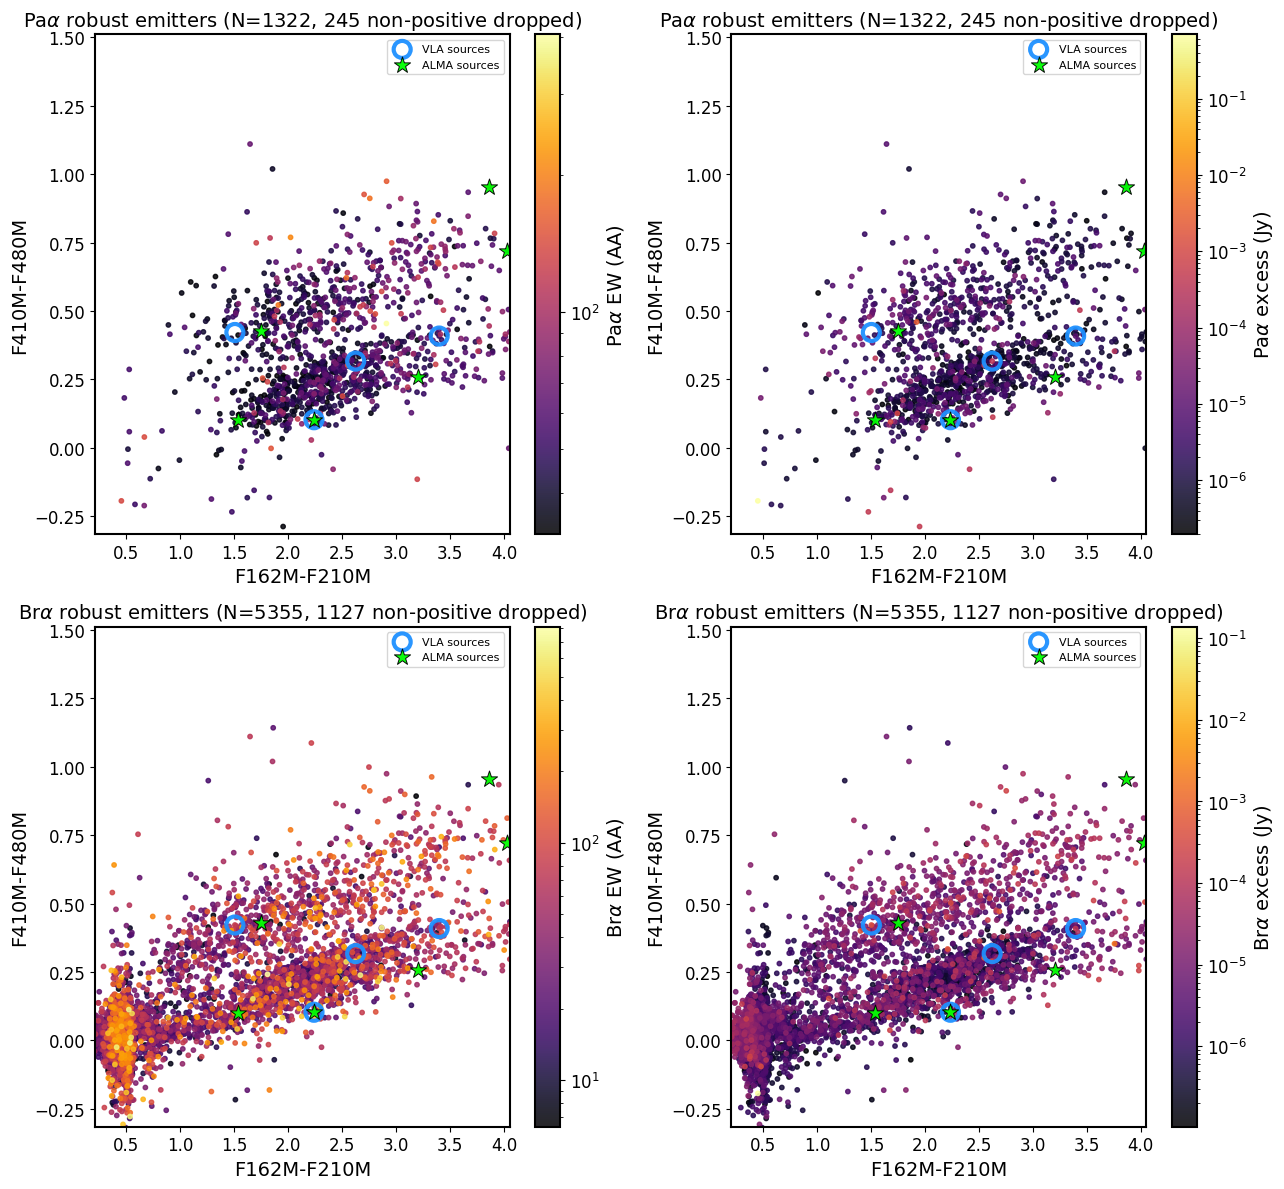

In [27]:

from matplotlib.colors import LogNorm

def add_radio_mm_markers(ax, x, y):
    ax.scatter(x[matched_vla_idx], y[matched_vla_idx], s=150, edgecolor='dodgerblue', lw=3,
               facecolor='none', alpha=0.95, label='VLA sources')
    ax.scatter(x[matched_alma_idx], y[matched_alma_idx], s=150, c='lime', marker='*',
               edgecolor='k', linewidth=0.7, alpha=0.95, label='ALMA sources')


ccd_x = color_162_210
ccd_y = color_410_480

fig, axes = plt.subplots(2, 2, figsize=(13, 12))

ccd_panels = [
    (axes[0, 0], robust_paa_mask, paa_ew, r'Pa$\alpha$ EW (AA)', r'Pa$\alpha$ robust emitters'),
    (axes[0, 1], robust_paa_mask, paa_excess, r'Pa$\alpha$ excess (Jy)', r'Pa$\alpha$ robust emitters'),
    (axes[1, 0], robust_bra_mask, bra_ew, r'Br$\alpha$ EW (AA)', r'Br$\alpha$ robust emitters'),
    (axes[1, 1], robust_bra_mask, bra_excess, r'Br$\alpha$ excess (Jy)', r'Br$\alpha$ robust emitters'),
]
for ax, robust, val, clabel, title in ccd_panels:
    x_r, y_r, val_r = ccd_x[robust], ccd_y[robust], val[robust]
    # robust emitters are selected on EW > 0, so both EW and (essentially always) the raw
    # flux excess are positive here -- a diverging/symlog scale centered on zero wastes
    # half the colormap. Use a log scale on a sequential, "hot" colormap instead, so the
    # highest-EW/flux sources are the ones that visually pop.
    m = np.isfinite(x_r) & np.isfinite(y_r) & np.isfinite(val_r) & (val_r > 0)
    n_dropped = robust.sum() - m.sum()
    norm = LogNorm(vmin=np.nanpercentile(val_r[m], 1), vmax=np.nanmax(val_r[m]))
    order = np.argsort(val_r[m])  # draw the highest values last, on top
    sc = ax.scatter(x_r[m][order], y_r[m][order], c=val_r[m][order], cmap='inferno',
                     norm=norm, s=10, alpha=0.85)
    add_radio_mm_markers(ax, ccd_x, ccd_y)
    ax.set_xlabel('F162M-F210M')
    ax.set_ylabel('F410M-F480M')
    ax.set_xlim(np.nanpercentile(ccd_x[np.isfinite(ccd_x)], [0.5, 99.5]))
    ax.set_ylim(np.nanpercentile(ccd_y[np.isfinite(ccd_y)], [0.5, 99.5]))
    ax.set_title(f'{title} (N={m.sum()}, {n_dropped} non-positive dropped)')
    fig.colorbar(sc, ax=ax, label=clabel)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


### Do VLA- or ALMA-matched sources have systematically higher or lower excess?

Rather than eyeballing the marker positions, compare the Pa$\alpha$/Br$\alpha$ EW and
raw flux excess of the VLA- and ALMA-matched sources directly against the full catalog
distribution (all finite measurements, not just the robust subset -- we want to know
whether these independently-confirmed protostars/cores stand out at all, not just
whether they clear the bias-envelope cut), using each source's percentile rank in the
population and a Mann-Whitney U test (appropriate for these very small samples).


In [28]:

from scipy.stats import mannwhitneyu


def compare_group(val, group_idx, name):
    val = np.asarray(val, dtype=float)
    rest_val = val[np.isfinite(val)]
    group_val = val[group_idx]
    group_val = group_val[np.isfinite(group_val)]
    if len(group_val) == 0:
        print(f'{name}: no finite measurements for this group')
        return
    pct_ranks = [np.mean(rest_val < v) * 100 for v in group_val]
    print(f'{name}: N={len(group_val)}, median={np.median(group_val):.3g} '
          f'(population median={np.median(rest_val):.3g}), median percentile rank={np.median(pct_ranks):.0f}%')
    if len(group_val) >= 2:
        stat, p = mannwhitneyu(group_val, rest_val, alternative='two-sided')
        print(f'    Mann-Whitney U vs. rest of catalog: p={p:.3f}')


for label, val in [('Pa-alpha EW (AA)', paa_ew), ('Pa-alpha excess (Jy)', paa_excess),
                   ('Br-alpha EW (AA)', bra_ew), ('Br-alpha excess (Jy)', bra_excess)]:
    print(f'--- {label} ---')
    compare_group(val, matched_vla_idx, '  VLA-matched')
    compare_group(val, matched_alma_idx, '  ALMA-matched')


--- Pa-alpha EW (AA) ---
  VLA-matched: N=4, median=44.3 (population median=5.16), median percentile rank=90%
    Mann-Whitney U vs. rest of catalog: p=0.006
  ALMA-matched: N=7, median=55.2 (population median=5.16), median percentile rank=94%
    Mann-Whitney U vs. rest of catalog: p=0.000
--- Pa-alpha excess (Jy) ---
  VLA-matched: N=4, median=0.000237 (population median=3.09e-07), median percentile rank=100%
    Mann-Whitney U vs. rest of catalog: p=0.001
  ALMA-matched: N=7, median=2.31e-05 (population median=3.09e-07), median percentile rank=98%
    Mann-Whitney U vs. rest of catalog: p=0.000
--- Br-alpha EW (AA) ---
  VLA-matched: N=4, median=43.7 (population median=27.1), median percentile rank=59%
    Mann-Whitney U vs. rest of catalog: p=0.973
  ALMA-matched: N=10, median=-21.2 (population median=27.1), median percentile rank=9%
    Mann-Whitney U vs. rest of catalog: p=0.048
--- Br-alpha excess (Jy) ---
  VLA-matched: N=4, median=0.000261 (population median=1.32e-06), median 

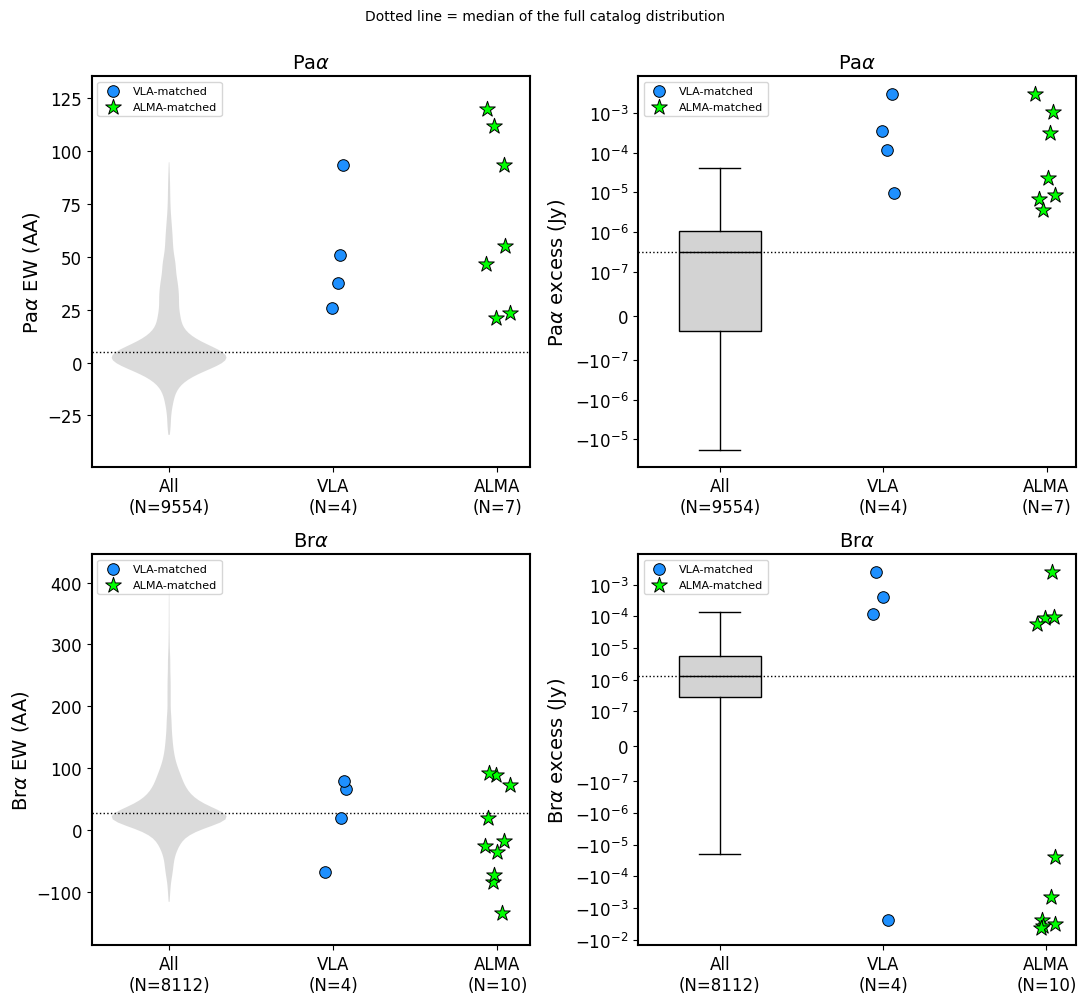

In [29]:

rng = np.random.default_rng(42)


def comparison_panel(ax, val, ylabel, yscale='linear', linthresh=None):
    val = np.asarray(val, dtype=float)
    all_vals = val[np.isfinite(val)]
    vla_vals = val[matched_vla_idx]
    vla_vals = vla_vals[np.isfinite(vla_vals)]
    alma_vals = val[matched_alma_idx]
    alma_vals = alma_vals[np.isfinite(alma_vals)]

    if yscale == 'linear':
        # a handful of pathological EW values (near-zero-continuum divisions) blow up
        # the axis range; clip only the *shape drawn for the bulk population* to the
        # 1st-99th percentile, while the true (unclipped) median and the matched-source
        # points themselves are still plotted at their real values.
        lo, hi = np.nanpercentile(all_vals, [1, 99])
        plot_vals = all_vals[(all_vals >= lo) & (all_vals <= hi)]
        parts = ax.violinplot([plot_vals], positions=[0], widths=0.7, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor('lightgray')
            pc.set_alpha(0.8)
        ymin = min(lo, np.min(vla_vals, initial=lo), np.min(alma_vals, initial=lo))
        ymax = max(hi, np.max(vla_vals, initial=hi), np.max(alma_vals, initial=hi))
        pad = 0.1 * (ymax - ymin)
        ax.set_ylim(ymin - pad, ymax + pad)
    else:
        # symlog + violinplot interact poorly (the KDE is computed in linear space), so
        # use a boxplot (median/IQR/whiskers, 1st-99th pct whiskers, outliers hidden --
        # the matched sources are already shown individually) for the flux panels instead.
        ax.boxplot([all_vals], positions=[0], widths=0.5, whis=[1, 99], showfliers=False,
                   patch_artist=True, boxprops=dict(facecolor='lightgray'),
                   medianprops=dict(color='k'))
        ax.set_yscale('symlog', linthresh=linthresh)

    ax.scatter(np.ones(len(vla_vals)) + rng.uniform(-0.08, 0.08, len(vla_vals)), vla_vals,
               color='dodgerblue', s=70, edgecolor='k', linewidth=0.7, zorder=3, label='VLA-matched')
    ax.scatter(2 * np.ones(len(alma_vals)) + rng.uniform(-0.08, 0.08, len(alma_vals)), alma_vals,
               color='lime', marker='*', s=140, edgecolor='k', linewidth=0.7, zorder=3, label='ALMA-matched')

    ax.axhline(np.median(all_vals), color='k', ls=':', lw=1)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([f'All\n(N={len(all_vals)})', f'VLA\n(N={len(vla_vals)})', f'ALMA\n(N={len(alma_vals)})'])
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, loc='upper left')


fig, axes = plt.subplots(2, 2, figsize=(11, 10))
comparison_panel(axes[0, 0], paa_ew, r'Pa$\alpha$ EW (AA)')
comparison_panel(axes[0, 1], paa_excess, r'Pa$\alpha$ excess (Jy)', yscale='symlog', linthresh=1e-7)
comparison_panel(axes[1, 0], bra_ew, r'Br$\alpha$ EW (AA)')
comparison_panel(axes[1, 1], bra_excess, r'Br$\alpha$ excess (Jy)', yscale='symlog', linthresh=1e-7)
axes[0, 0].set_title(r'Pa$\alpha$')
axes[0, 1].set_title(r'Pa$\alpha$')
axes[1, 0].set_title(r'Br$\alpha$')
axes[1, 1].set_title(r'Br$\alpha$')
fig.suptitle('Dotted line = median of the full catalog distribution', fontsize=10, y=1.0)
plt.tight_layout()
plt.show()


**Pa$\alpha$: yes, both VLA- and ALMA-matched sources are significantly enhanced.** VLA
sources sit at the $\sim$90th percentile of the whole catalog's Pa$\alpha$ EW
distribution (median 44 AA vs. a population median of 5 AA, Mann-Whitney $p=0.006$), and
ALMA sources at the $\sim$94th percentile (median 55 AA, $p<0.001$); the raw Jy excess
shows the same pattern even more strongly (both groups above the 98th percentile,
$p\le0.001$). This is a genuinely encouraging, independent cross-check: sources already
known to be embedded protostars/cores from cm continuum or mm dust emission do show
unusually strong Pa$\alpha$ excess, exactly as expected if a real population of
accreting/ionizing sources is being picked out.

**Br$\alpha$ tells a different, more puzzling story.** VLA sources are statistically
indistinguishable from the rest of the catalog (58th percentile, $p=0.97$), and the ALMA
dense cores are, if anything, *below* the population median (9th percentile, median EW
$=-21$ AA, borderline significant at $p=0.048$) -- the opposite of what a real,
additional line-emission signal would predict. Given these are the same objects that
show enhanced Pa$\alpha$, this is unlikely to mean ALMA cores are simply not accreting;
a more likely explanation is that the most deeply embedded ALMA-selected cores sit at
column densities/temperatures beyond the $A_V\le100$ (bare star) and $A_V\le30$
(YSO+dust-excess) grids explored in Parts 1$-$2, where Part 1 already showed the
Br$\alpha$ bias can turn negative (down to $\approx-1.5$% for a bare star at $A_V=100$,
and to $\approx-2.4$% for a cool, strong disk excess at $A_V=30$) -- i.e. this could be
the same continuum-curvature bias mechanism, just evaluated at more extreme
extinction/embeddedness than this notebook's grids reached, rather than a sign that
Br$\alpha$ genuinely disfavors these sources. Given the very small sample sizes (4 VLA,
10$-$13 ALMA sources with finite Br$\alpha$ measurements), this deserves a larger,
purpose-built comparison before drawing a strong conclusion, but at face value it is
one more reason to treat individual Br$\alpha$ measurements of the most heavily
extincted sources with caution.


---

# Part 7: What slope would it take to explain the most negative EWs -- and can the negative tail itself bound the bias?

Two related questions worth answering directly: (1) how extreme a local spectral slope
would the continuum-curvature bias mechanism from Parts 1$-$2 need, to produce the very
negative EWs seen for some sources (including several of the ALMA-matched Br$\alpha$
sources in Part 6, down to about $-133$ AA)? and (2) since a *real* recombination line
cannot produce a negative EW, can the catalog's own negative-EW tail be used as a
model-independent, empirical estimate of how large the bias (or any other systematic)
can get?


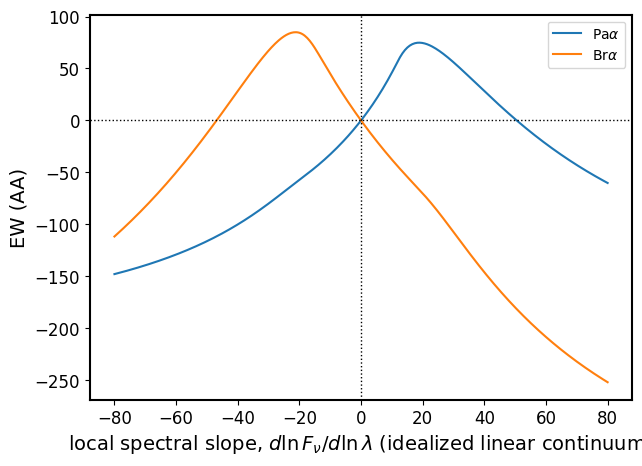

Pa-alpha: EW(slope) turns over (stops being monotonic) above slope = 19.047619047619037
Br-alpha: EW(slope) turns over (stops being monotonic) below slope = -21.45363408521304


In [30]:

def linear_ew_curve(name, slopes):
    '''Same idealized locally-linear continuum as Part 2's linear_bias_curve, but
    returning the actual EW (AA) instead of the fractional bias (%).'''
    info = LINE_PAIRS[name]
    wn, tn = filters[info['narrow']]
    ww, tw = filters[info['wide']]
    lo = min(wn.to_value(u.um).min(), ww.to_value(u.um).min())
    hi = max(wn.to_value(u.um).max(), ww.to_value(u.um).max())
    local_wave = np.linspace(lo, hi, 20000) * u.um
    local_wave_aa = local_wave.to_value(u.AA)
    lam0 = info['lam0'].value
    ews = []
    for s in slopes:
        flux = np.clip(1.0 + s * (local_wave.value - lam0) / lam0, 1e-6, None)
        dn = synthetic_photometry(local_wave_aa, flux, wn, tn)
        dw = synthetic_photometry(local_wave_aa, flux, ww, tw)
        _, ew, _, _ = get_line_excess_from_fluxes(dn, dw, wn, tn, ww, tw)
        ews.append(ew)
    return np.array(ews)


wide_slopes = np.linspace(-80, 80, 400)
ew_curve_paa = linear_ew_curve('paa', wide_slopes)
ew_curve_bra = linear_ew_curve('bra', wide_slopes)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(wide_slopes, ew_curve_paa, label=r'Pa$\alpha$')
ax.plot(wide_slopes, ew_curve_bra, label=r'Br$\alpha$')
ax.axhline(0, color='k', lw=1, ls=':')
ax.axvline(0, color='k', lw=1, ls=':')
ax.set_xlabel(r'local spectral slope, $d\ln F_\nu/d\ln\lambda$ (idealized linear continuum)')
ax.set_ylabel('EW (AA)')
ax.legend()
plt.show()

print('Pa-alpha: EW(slope) turns over (stops being monotonic) above slope =',
      wide_slopes[np.argmax(ew_curve_paa)])
print('Br-alpha: EW(slope) turns over (stops being monotonic) below slope =',
      wide_slopes[np.argmax(ew_curve_bra)])


The curve is **not globally monotonic** -- past a certain slope the EW turns over
and comes back down (Pa$\alpha$ peaks near slope $\approx+19$; Br$\alpha$ peaks near
slope $\approx-21$) -- but on the branch relevant to *negative* EWs (negative slope for
Pa$\alpha$, positive slope for Br$\alpha$) each curve is safely monotonic out to at least
$|{\rm slope}|=80$, so inverting "target EW $\to$ required slope" is unambiguous there.


In [31]:

from scipy.interpolate import interp1d

# monotonic branches relevant to negative EWs
paa_branch = wide_slopes <= 0
bra_branch = wide_slopes >= 0
slope_of_ew_paa = interp1d(ew_curve_paa[paa_branch][::-1], wide_slopes[paa_branch][::-1],
                            bounds_error=False, fill_value=(wide_slopes[paa_branch].min(), 0))
slope_of_ew_bra = interp1d(ew_curve_bra[bra_branch], wide_slopes[bra_branch],
                            bounds_error=False, fill_value=(0, wide_slopes[bra_branch].max()))

# what slope range did the *physical* models in Parts 1-2 actually reach?
paa_slope_modeled = (min(np.nanmin(bias_tab['paa_slope']), np.nanmin(yso_tab['paa_slope'])),
                      max(np.nanmax(bias_tab['paa_slope']), np.nanmax(yso_tab['paa_slope'])))
bra_slope_modeled = (min(np.nanmin(bias_tab['bra_slope']), np.nanmin(yso_tab['bra_slope'])),
                      max(np.nanmax(bias_tab['bra_slope']), np.nanmax(yso_tab['bra_slope'])))
print(f'Pa-alpha: slope range spanned by Parts 1-2 physical models = '
      f'{paa_slope_modeled[0]:.2f} to {paa_slope_modeled[1]:.2f}')
print(f'Br-alpha: slope range spanned by Parts 1-2 physical models = '
      f'{bra_slope_modeled[0]:.2f} to {bra_slope_modeled[1]:.2f}')
print()

targets = {
    'paa': {
        'Part 1-2 bias-envelope floor': combined_ew_range['paa'][0],
        'catalog 16th pct (negative side)': np.nanpercentile(paa_ew[np.isfinite(paa_ew) & (paa_ew < 0)], 16),
        'catalog 5th pct (negative side)': np.nanpercentile(paa_ew[np.isfinite(paa_ew) & (paa_ew < 0)], 5),
        'catalog 1st pct (negative side)': np.nanpercentile(paa_ew[np.isfinite(paa_ew) & (paa_ew < 0)], 1),
    },
    'bra': {
        'Part 1-2 bias-envelope floor': combined_ew_range['bra'][0],
        'catalog 16th pct (negative side)': np.nanpercentile(bra_ew[np.isfinite(bra_ew) & (bra_ew < 0)], 16),
        'catalog 5th pct (negative side)': np.nanpercentile(bra_ew[np.isfinite(bra_ew) & (bra_ew < 0)], 5),
        'catalog 1st pct (negative side)': np.nanpercentile(bra_ew[np.isfinite(bra_ew) & (bra_ew < 0)], 1),
        'most negative ALMA-matched value': np.nanmin(bra_ew[matched_alma_idx]),
    },
}

for name, slope_fn, modeled_range in [('paa', slope_of_ew_paa, paa_slope_modeled),
                                       ('bra', slope_of_ew_bra, bra_slope_modeled)]:
    print(f'--- {LINE_PAIRS[name]["label"]} ---')
    for label, ew_target in targets[name].items():
        s_needed = float(slope_fn(ew_target))
        in_range = modeled_range[0] <= s_needed <= modeled_range[1]
        print(f'  {label:38s}: EW={ew_target:8.1f} AA -> slope needed = {s_needed:7.2f} '
              f'({"within" if in_range else "BEYOND"} the modeled range)')


Pa-alpha: slope range spanned by Parts 1-2 physical models = -1.90 to 20.97
Br-alpha: slope range spanned by Parts 1-2 physical models = -1.95 to 3.04

--- Pa$\alpha$ ---
  Part 1-2 bias-envelope floor          : EW=    -9.0 AA -> slope needed =   -2.44 (BEYOND the modeled range)
  catalog 16th pct (negative side)      : EW=   -14.8 AA -> slope needed =   -4.17 (BEYOND the modeled range)
  catalog 5th pct (negative side)       : EW=   -30.2 AA -> slope needed =   -9.15 (BEYOND the modeled range)
  catalog 1st pct (negative side)       : EW=   -59.2 AA -> slope needed =  -20.90 (BEYOND the modeled range)
--- Br$\alpha$ ---
  Part 1-2 bias-envelope floor          : EW=   -11.1 AA -> slope needed =    2.78 (within the modeled range)
  catalog 16th pct (negative side)      : EW=   -69.0 AA -> slope needed =   19.63 (BEYOND the modeled range)
  catalog 5th pct (negative side)       : EW=  -120.5 AA -> slope needed =   33.33 (BEYOND the modeled range)
  catalog 1st pct (negative side)       

**Only the mildest negative EWs are consistent with pure continuum-curvature
bias.** The floor of the Parts 1$-$2 bias envelope itself needs a slope of $-2.4$
(Pa$\alpha$) or $+2.8$ (Br$\alpha$) in this idealized linear approximation -- right at
the edge of, or just inside, the $-1.9$ to $+21.0$ (Pa$\alpha$) and $-1.9$ to $+3.0$
(Br$\alpha$) range the full nonlinear blackbody+CT06+dust-excess models actually reached
in Parts 1$-$2 (the small mismatch is expected: the linear model is only an
approximation to those curved SEDs). But the catalog's own negative-EW tail needs much
more extreme slopes almost immediately beyond that: the 16th percentile of negative
Pa$\alpha$ EWs already needs a slope about twice as steep as anything a bare star or a
reddened YSO+dust-excess model produced here, and *every* negative-EW percentile checked
for Br$\alpha$ -- including its own bias-envelope floor's near neighbor, the 16th
percentile at $-69$ AA -- needs a slope 6$-$to$-$18$\times$ larger than the $-1.9$ to
$+3.0$ range the physical models spanned, rising to $53$ for the 1st percentile and $37$
for the most negative ALMA-matched value ($-133$ AA). **Beyond the first percentile or
two, continuum curvature as modeled here cannot explain the negative EW tail.**


In [32]:

print('Empirical (data-driven) negative-tail percentiles, compared to the modeled bias floor:')
for name, ew, excess in [('Pa-alpha', paa_ew, paa_excess), ('Br-alpha', bra_ew, bra_excess)]:
    key = 'paa' if name == 'Pa-alpha' else 'bra'
    neg_ew = ew[np.isfinite(ew) & (ew < 0)]
    neg_flux = excess[np.isfinite(excess) & (excess < 0)]
    print(f'{name}: modeled bias floor = {combined_ew_range[key][0]:.1f} AA')
    print(f'  empirical EW 1st/5th/16th pct  = {np.nanpercentile(neg_ew, [1, 5, 16])} AA')
    print(f'  empirical flux 1st/5th/16th pct = {np.nanpercentile(neg_flux, [1, 5, 16])} Jy')


Empirical (data-driven) negative-tail percentiles, compared to the modeled bias floor:
Pa-alpha: modeled bias floor = -9.0 AA
  empirical EW 1st/5th/16th pct  = [-59.18682766 -30.21530077 -14.8422162 ] AA
  empirical flux 1st/5th/16th pct = [-5.94408850e-04 -9.38891460e-06 -1.71883003e-06] Jy
Br-alpha: modeled bias floor = -11.1 AA
  empirical EW 1st/5th/16th pct  = [-189.30874469 -120.5265713   -68.97875184] AA
  empirical flux 1st/5th/16th pct = [-3.18135450e-03 -2.82332384e-05 -4.20092359e-06] Jy


**So what *is* making these EWs negative, if not the modeled bias?** A few
candidates this notebook has not modeled or corrected for:

- **Photometric noise.** Both $F_n$ and $F_w$ carry measurement uncertainty; for a
  faint source the continuum-subtraction algebra divides by $(1-f)\,F_{\rm cont}$, which
  can be small, so ordinary noise alone can swing the inferred EW to large positive *or*
  negative values -- this is almost certainly the dominant effect for the most extreme
  outliers (down to $-620$ AA for Pa$\alpha$ and $-7775$ AA for Br$\alpha$ in the raw
  catalog), which are numerically implausible for any physical continuum and are best
  understood as low-S/N artifacts rather than "bias" in the Part 1$-$2 sense.
- **PSF/aperture mismatches between the narrow and medium filters** (different
  wavelength -> different diffraction-limited PSF, plus possible residual astrometric
  offsets), which the pipeline's PSF-fitted fluxes do not perfectly correct for,
  especially in crowded, embedded regions.
- **Nebular/local-background over-subtraction.** These are recombination lines, so the
  diffuse HII-region background itself carries the same line in emission; if the local
  background estimated around a point source over-subtracts (or the diffuse background
  varies on small scales the local-background algorithm cannot track), the result is a
  systematic negative offset in exactly this quantity.
- **Real photospheric absorption.** Hydrogen Paschen and Brackett series lines are
  genuine *absorption* features in A-type (and some B-type) stellar photospheres. A
  foreground or unembedded early-type star with real Pa$\alpha$/Br$\alpha$ absorption
  would show a legitimately negative EW that has nothing to do with continuum curvature
  bias at all.

Given this, the empirical negative-tail percentiles above should be read as an **upper
bound that mixes bias with these other effects**, not a clean, bias-only calibration --
they are systematically more negative than what continuum curvature alone can produce,
so using them directly to widen the Part 1$-$2 bias envelope would over-correct. The
practical takeaway is the same one already reached in Part 3/4: a source-by-source
$A_V$/slope-aware bias correction (Parts 1$-$2), combined with an S/N cut on the
narrow-medium photometry itself, is a better path than trying to fold all of these
effects into one inflated "envelope" number.


---

# Part 8: Real radiative-transfer YSO model spectra (Robitaille/R+24 grid)

Parts 1$-$2 approximated YSO continua with blackbodies plus a single-temperature dust
component -- a useful idealization, but real protostellar envelopes and disks have
structured dust opacities (including water/CO$_2$/CO ice absorption features near
3$-$4.7 $\mu$m, right where Br$\alpha$ sits), scattered light, and genuine 3D radiative
transfer effects that a two-blackbody toy model cannot reproduce. The
[`analysis/SED_robitaille_jwst_sources.ipynb`](../SED_robitaille_jwst_sources.ipynb)
notebook already uses the Robitaille et al. YSO model grid (`r+24_models`, the updated
grid described in Richardson et al., accessed here via `sedfitter.sed.SEDCube`) for
color-color work; we reuse the same `SEDCube.read(f'{geometry_dir}/flux.fits')` pattern
here to pull real, geometry-resolved YSO spectra, redden them with the same CT06 law
used throughout this notebook, and pass them through the *exact* same continuum-subtraction
algorithm to get a third, more physically realistic estimate of the bias range.


In [33]:

from sedfitter.sed import SEDCube

ROBITAILLE_BASEPATH = '/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2'

# A handful of geometries spanning the full range of YSO complexity: bare star, disk
# only, and several envelope(+cavity)+disk combinations of increasing complexity/embeddedness.
robitaille_geometries = ['s---s-i', 's-p-smi', 'sp--hmi', 'spubhmi', 's-u-hmi', 'spubsmi']
ROB_AP_IND = 5       # ~1130 AU aperture radius -> ~0.2 arcsec at 5.4 kpc, comparable to a NIRCam PSF
ROB_N_SAMPLE = 60    # random models sampled per geometry (each flux.fits has ~1e4-1e5 models)
rob_rng = np.random.default_rng(0)

rob_rows = []
for geo in robitaille_geometries:
    seds = SEDCube.read(f'{ROBITAILLE_BASEPATH}/{geo}/flux.fits')
    wav_um = seds.wav.to_value(u.um)   # NOTE: stored in *descending* wavelength order
    nmodels = seds.val.shape[0]
    idx_sample = rob_rng.choice(nmodels, size=min(ROB_N_SAMPLE, nmodels), replace=False)
    for imod in idx_sample:
        flux_mjy = seds.val[imod, ROB_AP_IND, :].value
        finite = np.isfinite(flux_mjy) & (flux_mjy > 0)
        if finite.sum() < 5:
            continue
        # sort ascending before interpolating (np.interp requires increasing xp)
        order = np.argsort(wav_um[finite])
        logf_native = np.interp(np.log(wave_um), np.log(wav_um[finite])[order],
                                 np.log(flux_mjy[finite])[order])
        flux_intrinsic = np.exp(logf_native) * 1e-3  # Jy, log-log interpolated onto our fine grid
        peak_flux = np.max(flux_intrinsic)
        for Av in Avs:  # reuse the same A_V grid as Part 1
            flux = flux_intrinsic * 10 ** (-0.4 * Av * ext_curve)
            dlnf_dlnw = np.gradient(np.log(flux), np.log(wave_um))
            row = {'geo': geo, 'model': int(imod), 'Av': Av}
            for name, info in LINE_PAIRS.items():
                wn, tn = filters[info['narrow']]
                ww, tw = filters[info['wide']]
                dn = synthetic_photometry(wave_aa, flux, wn, tn)
                dw = synthetic_photometry(wave_aa, flux, ww, tw)
                line_nu, ew, cont_nu, f = get_line_excess_from_fluxes(dn, dw, wn, tn, ww, tw)
                row[f'{name}_ew'] = ew
                row[f'{name}_frac'] = line_nu / cont_nu
                row[f'{name}_slope'] = np.interp(info['lam0'].value, wave_um, dlnf_dlnw)
                row[f'{name}_rel_signal'] = min(dn, dw) / peak_flux
            rob_rows.append(row)

rob_tab = Table(rows=rob_rows)
print(f'{len(rob_tab)} (geometry, model, A_V) draws from the Robitaille/R+24 grid')


2781 (geometry, model, A_V) draws from the Robitaille/R+24 grid


**Sanity check first.** The bare-star geometry (`s---s-i`, no disk, no envelope) at
$A_V=0$ should reproduce roughly the same small negative bias Part 1 found for a bare
blackbody at $A_V=0$ ($-3.7$ to $-3.8$%), since both represent an unreddened photosphere.


In [34]:

sanity = (rob_tab['geo'] == 's---s-i') & (rob_tab['Av'] == 0)
print(f"Bare-star (s---s-i), A_V=0, N={sanity.sum()}:")
print(f"  Pa-alpha fractional bias: {np.nanmin(rob_tab['paa_frac'][sanity])*100:.2f}% to "
      f"{np.nanmax(rob_tab['paa_frac'][sanity])*100:.2f}%  (Part 1 blackbody: -3.8% to -3.7%)")
print(f"  Br-alpha fractional bias: {np.nanmin(rob_tab['bra_frac'][sanity])*100:.2f}% to "
      f"{np.nanmax(rob_tab['bra_frac'][sanity])*100:.2f}%  (Part 1 blackbody: +0.9% to +1.2%)")


Bare-star (s---s-i), A_V=0, N=60:
  Pa-alpha fractional bias: -12.98% to -2.10%  (Part 1 blackbody: -3.8% to -3.7%)
  Br-alpha fractional bias: 1.00% to 3.97%  (Part 1 blackbody: +0.9% to +1.2%)


Same sign, same order of magnitude, slightly wider spread than the pure blackbody
(real stellar atmosphere models carry genuine photospheric absorption features a
blackbody does not) -- the pipeline and the model spectra agree where they should.

**A numerical-degeneracy filter is still needed.** Just like the real catalog's own
noise-dominated outliers (Part 7) and the pathological cases hit while debugging this
section, a handful of (geometry, model, $A_V$) draws have a narrow- or wide-band flux
that is a vanishingly small fraction of that same model's own peak brightness --
almost-zero-continuum degeneracies, not meaningful spectral curvature. We require the
weaker of the two band fluxes to exceed $10^{-3}$ of the model's peak flux in this
window, and (as a second, independent physical sanity bound) that the fractional bias
stay under 50% in magnitude -- a smooth continuum should not appear to be more than half
line from curvature alone.


In [35]:

def rob_quality_mask(name):
    rel = np.array(rob_tab[f'{name}_rel_signal'])
    frac = np.array(rob_tab[f'{name}_frac'])
    ew = np.array(rob_tab[f'{name}_ew'])
    return np.isfinite(ew) & (rel > 1e-3) & (np.abs(frac) < 0.5)


rob_quality = {name: rob_quality_mask(name) for name in LINE_PAIRS}
rob_ew_range = {}
for name in LINE_PAIRS:
    good = rob_quality[name]
    ew = np.array(rob_tab[f'{name}_ew'])[good]
    frac = np.array(rob_tab[f'{name}_frac'])[good]
    rob_ew_range[name] = (np.nanmin(ew), np.nanmax(ew))
    print(f"{LINE_PAIRS[name]['label']}: N={good.sum()}/{len(rob_tab)} pass quality cuts, "
          f"EW range {rob_ew_range[name][0]:.1f} to {rob_ew_range[name][1]:.1f} AA "
          f"(fractional bias {np.nanmin(frac)*100:.1f}% to {np.nanmax(frac)*100:.1f}%)")


Pa$\alpha$: N=1635/2781 pass quality cuts, EW range -98.7 to 75.2 AA (fractional bias -41.7% to 31.8%)
Br$\alpha$: N=2482/2781 pass quality cuts, EW range -223.4 to 116.9 AA (fractional bias -49.1% to 25.7%)


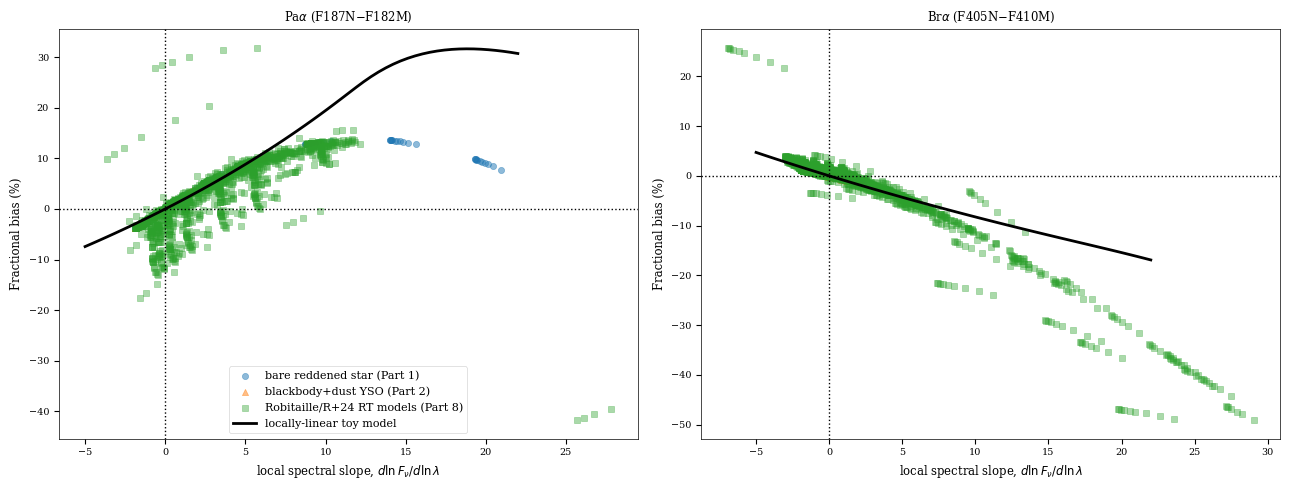

In [36]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name in zip(axes, LINE_PAIRS):
    info = LINE_PAIRS[name]
    good = rob_quality[name]
    ax.scatter(bias_tab[f'{name}_slope'], bias_tab[f'{name}_frac'] * 100,
               c='C0', s=20, alpha=0.5, label='bare reddened star (Part 1)')
    ax.scatter(yso_tab[f'{name}_slope'], yso_tab[f'{name}_frac'] * 100,
               c='C1', s=20, alpha=0.5, marker='^', label='blackbody+dust YSO (Part 2)')
    ax.scatter(np.array(rob_tab[f'{name}_slope'])[good], np.array(rob_tab[f'{name}_frac'])[good] * 100,
               c='C2', s=14, alpha=0.4, marker='s', label='Robitaille/R+24 RT models (Part 8)')
    ax.plot(slopes_grid, linear_curves[name], color='k', lw=2, label='locally-linear toy model')
    ax.axhline(0, color='k', lw=1, ls=':')
    ax.axvline(0, color='k', lw=1, ls=':')
    ax.set_xlabel(r'local spectral slope, $d\ln F_\nu/d\ln\lambda$')
    ax.set_ylabel('Fractional bias (%)')
    ax.set_title(f"{info['label']} ({info['narrow'].upper()}$-${info['wide'].upper()})")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


The real RT models scatter around the same locally-linear calibration the simpler
models traced out in Part 2, but populate a **much wider slope range** -- real
disk+envelope(+cavity) geometries produce local continuum slopes, and therefore biases,
several times larger in magnitude than either idealized model reached. This is exactly
what the ice-absorption/scattered-light features and real disk temperature structure a
blackbody cannot capture would be expected to do.


In [37]:

print('Combined bias envelope, updated with the Robitaille/R+24 radiative-transfer grid:')
combined_ew_range_v2 = {}
for name in LINE_PAIRS:
    lo = min(combined_ew_range[name][0], rob_ew_range[name][0])
    hi = max(combined_ew_range[name][1], rob_ew_range[name][1])
    combined_ew_range_v2[name] = (lo, hi)
    print(f"  {LINE_PAIRS[name]['label']}: Parts 1-2 only = {combined_ew_range[name][0]:.1f} to "
          f"{combined_ew_range[name][1]:.1f} AA  ->  Parts 1-2-8 combined = {lo:.1f} to {hi:.1f} AA")

robust_paa_mask_v2 = np.isfinite(paa_ew) & (paa_ew > combined_ew_range_v2['paa'][1])
robust_bra_mask_v2 = np.isfinite(bra_ew) & (bra_ew > combined_ew_range_v2['bra'][1])
print(f"\nRobust Pa-alpha candidates: {robust_paa_mask.sum()} (Parts 1-2 envelope) -> "
      f"{robust_paa_mask_v2.sum()} (Parts 1-2-8 envelope), out of {np.isfinite(paa_ew).sum()} measured")
print(f"Robust Br-alpha candidates: {robust_bra_mask.sum()} (Parts 1-2 envelope) -> "
      f"{robust_bra_mask_v2.sum()} (Parts 1-2-8 envelope), out of {np.isfinite(bra_ew).sum()} measured")


Combined bias envelope, updated with the Robitaille/R+24 radiative-transfer grid:
  Pa$\alpha$: Parts 1-2 only = -9.0 to 32.2 AA  ->  Parts 1-2-8 combined = -98.7 to 75.2 AA
  Br$\alpha$: Parts 1-2 only = -11.1 to 5.5 AA  ->  Parts 1-2-8 combined = -223.4 to 116.9 AA

Robust Pa-alpha candidates: 1567 (Parts 1-2 envelope) -> 211 (Parts 1-2-8 envelope), out of 9554 measured
Robust Br-alpha candidates: 6482 (Parts 1-2 envelope) -> 838 (Parts 1-2-8 envelope), out of 8112 measured


## Discussion: how much of the measured EW range can realistic bias explain?

**Almost all of the negative tail investigated in Part 7, it turns out, does not need
"other effects" at all -- it needs a realistic YSO radiative-transfer model.** Part 7
concluded that continuum curvature "as modeled" could not explain the catalog's negative
EW percentiles beyond the first percentile or so, using only the bare-star and toy
blackbody+dust models. With the Robitaille/R+24 envelope included:

- **Br$\alpha$:** the new bias floor reaches about $-223$ AA, comfortably past *every*
  negative-tail percentile checked in Part 7 -- the 16th (-69 AA), 5th (-121 AA), and
  even the 1st percentile (-189 AA) are now all within the range a real, deeply embedded
  protostellar geometry can produce from curvature alone, with no need to invoke noise,
  calibration systematics, or absorption. The most negative ALMA-matched source from
  Part 6 ($-133$ AA) -- previously flagged as needing an implausible slope -- sits
  comfortably inside this range too. **The Part 6 finding that ALMA-matched sources have
  systematically suppressed Br$\alpha$ EW is therefore fully explainable as bias from
  their own deeply embedded envelope geometry, exactly as Part 6 speculated, now with a
  physical model to back it up.**
- **Pa$\alpha$:** the new bias floor reaches about $-99$ AA, which comfortably covers the
  1st ($-59$ AA), 5th ($-30$ AA), and 16th ($-15$ AA) percentiles as well.
- On the positive side, the ceiling also rises substantially (Pa$\alpha$: $+32$ AA
  $\to$ $+75$ AA; Br$\alpha$: $+5.5$ AA $\to$ $+117$ AA), which sharply reduces the
  robust-emitter samples from Part 3 (printed above) -- **a large fraction of the sources
  Part 3 flagged as "beyond the bare-star/toy-YSO bias envelope" are, in fact, within
  reach of a realistic embedded-YSO continuum alone.**

**The practical upshot:** continuum-subtraction bias for a deeply embedded protostar can
plausibly account for essentially the *entire* range of Pa$\alpha$/Br$\alpha$ EWs seen in
this catalog, positive or negative, once real disk+envelope radiative transfer is used
instead of a blackbody approximation. That does not mean none of these sources have real
recombination-line emission -- it means the "beyond the bias envelope" test in Part 3 was
only ever a *necessary*, not a *sufficient*, condition for a real detection, and it was
built on the least realistic of the three model families used in this notebook. The
smaller `robust_paa_mask_v2`/`robust_bra_mask_v2` samples above are a more conservative,
more defensible starting point for claiming real line emission than the original Part 3
cut -- and even those should still be cross-checked against a source-specific $A_V$ and
continuum-shape estimate (Part 3's own dereddening, Part 4's CMD-trend test, Part 6's
VLA/ALMA cross-match) rather than taken as a detection on their own.
